# Table of Contents

- [Abstract](#abstract)
- [Introduction](#introduction)
- [Methodology](#methodology)
  - [Architectural Components – A Synthesis](#architectural-components--a-synthesis)
  - [Setting seed for reproducibility](#setting-seed-for-reproducibility)
  - [EDA - Initial File Investigation](#eda---initial-file-investigation)
  - [Building the Tissue Graph from `tissue.hierarchy`](#building-the-tissue-graph-from-tissuehierarchy)
  - [Mapping Tissues to BTO IDs](#mapping-tissues-to-bto-ids)
  - [Data Acquisition and Pre-processing](#data-acquisition-and-pre-processing)
  - [Handling Labels (Tissues)](#handling-labels-tissues)
  - [Function to count PPIs for pre- and post-propagation sanity check](#function-to-count-ppis-for-pre--and-post-propagation-sanity-check)
  - [Hierarchical Consistency Check (Pre-Propagation)\nLet's verify why label propagation is necessary by checking the ground truth labels.](#hierarchical-consistency-check-pre-propagationnlets-verify-why-label-propagation-is-necessary-by-checking-the-ground-truth-labels)
  - [Sanity Check – PPI Counts Before and After Label Propagation](#sanity-check--ppi-counts-before-and-after-label-propagation)
  - [Identifying novel tissues after propagation](#identifying-novel-tissues-after-propagation)
  - [EDA - Visualizing our Labels](#eda---visualizing-our-labels)
  - [Splitting the data](#splitting-the-data)
  - [Data leakage check](#data-leakage-check)
  - [Node2Vec Tissue Embeddings](#node2vec-tissue-embeddings)
  - [Visualizing the tissue hierarchy](#visualizing-the-tissue-hierarchy)
  - [Neural Network Architecture](#neural-network-architecture)
  - [Custom Loss Function](#custom-loss-function)
  - [Inference](#inference)
  - [Technical Specifications](#technical-specifications)
  - [Hyperparameters](#hyperparameters)
  - [THE TRAINING LOOP](#the-training-loop)
  - [Extract attention coefficients](#extract-attention-coefficients)
- [Results](#results)
  - [Architectural Design: Width vs Depth](#architectural-design-width-vs-depth)
  - [Plotting loss curves](#plotting-loss-curves)
  - [Dual-Objective Optimization Dynamics](#dual-objective-optimization-dynamics)
  - [Load model](#load-model)
  - [Custom Loss Function – λ and HV](#custom-loss-function---and-hv)
  - [The Effect of Dropout on Convergence](#the-effect-of-dropout-on-convergence)
  - [Testing Results](#testing-results)
  - [Confusion Matrix, Precision, Recall, AUROC and AUPRC](#confusion-matrix-precision-recall-auroc-and-auprc)
  - [Final Results](#final-results)
  - [Hub protein analysis](#hub-protein-analysis)
  - [Attention weights: Attention "collected" by protein 1956](#attention-weights-attention-collected-by-protein-1956)
  - [Plotting attention weights](#plotting-attention-weights)
  - [Attenttion coefficient - "Hub" protein 1956 reporting](#attenttion-coefficient---hub-protein-1956-reporting)
  - [Hierarchical violations](#hierarchical-violations)
  - [Model Hierarchy Analysis](#model-hierarchy-analysis)
  - [Close wandb](#close-wandb)
- [Discussion](#discussion)
  - [Architectural Comparison: Width vs Depth](#architectural-comparison-width-vs-depth)
  - [Custom Loss Function When Unbound and Hyper-constrained](#custom-loss-function-when-unbound-and-hyper-constrained)
  - [Dropout and Convergence](#dropout-and-convergence)
  - [Final Results](#final-results)
  - [Confusion Matrix: Classification Performance](#confusion-matrix-classification-performance)
  - [Attention budget: Hub Proteins and Attention Dilution](#attention-budget-hub-proteins-and-attention-dilution)
  - [The OhmNet Framework](#the-ohmnet-framework)
  - [Computational Efficiency and Telemetry Overhead](#computational-efficiency-and-telemetry-overhead)
- [References](#references)


# Capstone Project – GNN for PPI Tissue Prediction

**Steven Ravary – 40211451** - 
 COMP6841 – Final Project - 
*Presented to Instructor Tri Minh Triet and Firat Oncel (TA) — May 1st, 2026*


## Abstract

This study develops a Deep Learning extension of the OhmNet framework to improve the prediction of tissue-specific protein-protein interactions (PPIs). While traditional models often treat biological tissues as independent entities, this research implements a hierarchy-aware architecture that enforces the **"True Path Rule"**—a fundamental biological principle requiring that interactions in specialized child tissues be consistently represented in their parent organs. This clinical constraint is vital for pharmacovigilance and drug-discovery applications, where logical consistency across anatomical structures is necessary for model reliability.

The methodology utilizes a late-fusion Graph Attention Network (GAT-MLP) integrated with 256-dimensional Node2Vec tissue embeddings to capture the complexity of the BRENDA Tissue Ontology. A primary focus of this work was the development of a dynamic penalty scheduling system to manage the **"objective competition"** between classification accuracy and hierarchical consistency. Experimental results on an NVIDIA RTX 3090 Ti demonstrate that an unconstrained penalty leads to catastrophic loss divergence, whereas a capped, rule-based multiplier (λ) allows the model to satisfy biological constraints without sacrificing predictive power. The final architecture achieves a **Macro-AUROC of 0.995** and reduces hierarchical violations to **less than 1%**, proving that artificial intelligence can respect fundamental biology without sacrificing accuracy, making it a highly trustworthy tool for medical researchers and drug developers.

## Introduction

The purpose of this project was to build a Deep Learning extension of a study on prediction of tissue-specific protein-protein interactions (PPIs) [[1]](#references) by building a tissue hierarchy-aware, edge prediction, late-fusion GAT-MLP model. The original work, the OhmNet framework, is a multi-label classification task that introduced a regularization method that factored ontological hierarchy. Every protein in the network was assigned zero, one or more tissue-specific cellular functions for the classifier to be trained on features from other tissues. It also featured a transfer learning component where they predicted "cellular functions for a protein in one tissue based on classifiers trained on features from other tissues" [[1]](#references). Finally, they performed a network-embedding of tissues for visualization in 2D space.

The approach of this work is to perform a similar set of prediction tasks but this time using semi-supervised learning and high-dimensional embeddings for tissue hierarchy. A late-fusion [[2]](#references) GAT-MLP model was used for training assisted by a high-dimensional hierarchical tissue embedding system. The loss function used is `BCELoss()` with an added modular regularization component called the hierarchical penalty (λ × penalty). While the original OhmNet framework generated embeddings for 219 tissues, it utilized a limited training set of 144 tissues, evaluating performance specifically on 107 leaf nodes. In this work, we implemented bottom-up label propagation based on the **True Path Rule** [[3]](#references) to address the 75 parent nodes absent from the original training data. Label propagation was felt necessary for two reasons:

1. Without representing these 75 parent nodes, the GAT-MLP would be unable to map the hierarchical relationships captured by the high-dimensional embeddings to actual protein interaction patterns. Propagation ensures the model learns the inheritance of biological function across all 219 nodes in the embedding space.
2. Since the custom loss function explicitly penalizes hierarchical violations (HV), the presence of 'hidden' parent interactions (labeled as 0 in the original sparse data despite children being 1) would have artificially inflated the penalty term. Propagating the labels prevents these 'false violations' from dominating the gradient, thereby stabilizing the training dynamics and allowing the BCE loss to converge meaningfully.

With label propagation, it was possible to reduce the un-penalized hierarchical violation rate from around **64%** to a more realistic **22%**, a better starting point.

The primary objective of this work is to evaluate whether modern GNN architectures can surpass the original OhmNet benchmark of **0.756 AUROC** across 107 leaf-node tissues. By transitioning from traditional regularization to a deep-learning-based attention model, the hope is to show that Deep Learning architectures can be applied to traditional problems to increase the reliability of the results through the analysis of relevant metrics, all while demonstrating biological consistency through hierarchical tissue violation rates.

It is important to acknowledge that the significant performance gains observed in this work—including an AUROC of **0.9951**—cannot be viewed as a direct longitudinal comparison to the original OhmNet benchmark. The introduction of bottom-up label propagation and the Dynamic Hierarchical Penalty fundamentally shifts the problem from the sparse, unconstrained optimization of the 2017 study to a biologically-consistent, semi-supervised framework.

While the original OhmNet framework utilized an indirect maximization algorithm based on manifold regularization to encourage hierarchical similarity, this work introduces the penalty as a novel **Ontological Evaluator**. By moving from a hidden regularization term to an explicit penalty, a transparent metric for 'Biological Consistency' that directly quantifies the model's adherence to biological logic in real-time is provided—a dimension of validation that was not directly measurable in the original study.

However, as a Deep Learning evolution of the OhmNet project, these results (AUROC, AUPRC, Macro-F1, and Micro-F1) remain entirely valid. Rather than merely optimizing for a specific metric, this work demonstrates that by aligning modern GNN architectures with the logical constraints of the True Path Rule, we can achieve higher predictive reliability without sacrificing biological integrity. The results presented here represent the upper bound of performance attainable when structural anatomical priors are successfully integrated into the learning process.


---

## Methodology

### Architectural Components – A Synthesis

A Directed Acyclic Graph (DAG) of the 219 tissues used in the study was constructed using NetworkX [[4]](#references)[[5]](#references)[[6]](#references)[[7]](#references) and embeddings were generated with Node2Vec [[8]](#references)[[9]](#references). With assistance in the labeling logic, bottom-up label propagation was performed to adhere to the True Path Rule, which increased label density from **23.8%** to **38.3%** while maintaining the same **30.5%** label density for the 107 leaf tissues. The label propagation was verified to involve the complete set of 219 tissues—an increase from the original 144—and the 75 tissues to which labels were propagated were identified. A multi-hot tissue adjacency matrix based on **3.6M PPIs** (144 tissues of which 107 are leaf nodes used for testing) was generated using the OhmNet PPI dataset [[10]](#references).

The model originally utilized two GAT layers with 16–1 heads to learn contextual protein representations, using ELU activation in the hidden layer [[11]](#references). With further analysis of the results and state-of-the-art GAT models, a **3-layer 8-8-1 GAT** was adopted to better represent PPI and neighborhood features. These learned features are then concatenated with the pre-trained Node2Vec tissue embeddings in a **Late Fusion** layer. This combined representation is processed by a 1-layer MLP (ReLU-activated) whose final linear outputs are passed through a Sigmoid function to generate multi-label interaction probabilities. The model is optimized using binary cross-entropy (BCE) augmented by a custom hierarchical violation penalty to ensure biological consistency across the tissue ontology.


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch_geometric
from torch_geometric.utils import to_undirected
from torch_geometric.nn import GATConv
from torch_geometric.nn.conv import GATv2Conv
from torch_geometric.data import Data, Batch
from torch_geometric.loader import DataLoader, LinkNeighborLoader
from torch_geometric.nn import Node2Vec
from torch_geometric.nn.inits import glorot
import pandas as pd
import numpy as np
import networkx as nx
import os
import shutil
from pathlib import Path
import matplotlib.pyplot as plt
import gensim
from gensim.models.poincare import PoincareModel
import sklearn
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import gc
import pronto
from pronto import Ontology
from sklearn.model_selection import train_test_split
import random
import sys

# Checking if the GPU is active
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device used: {device}")

if device.type == 'cuda':
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Capability: {torch.cuda.get_device_capability(0)}")
    print(f"Total Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    
    # Current Memory Status
    allocated = torch.cuda.memory_allocated(0) / 1e9
    reserved = torch.cuda.memory_reserved(0) / 1e9
    print(f"Memory Allocated: {allocated:.2f} GB")
    print(f"Memory Reserved: {reserved:.2f} GB")
    
    # Multi-processor count (useful for understanding parallel processing power)
    print(f"Multi-processor count: {torch.cuda.get_device_properties(0).multi_processor_count}")

print(f"\nPyTorch version: {torch.__version__}")
print(f"PyTorch Geometric version: {torch_geometric.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"NetworkX version: {nx.__version__}")
print(f"Gensim version: {gensim.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")
print(f"Pronto version: {pronto.__version__}")

# Data files location
data_dir = Path('./data')

Device used: cuda
GPU Name: NVIDIA GeForce RTX 3090 Ti
CUDA Capability: (8, 6)
Total Memory: 25.76 GB
Memory Allocated: 0.00 GB
Memory Reserved: 0.00 GB
Multi-processor count: 84

PyTorch version: 2.5.1+cu121
PyTorch Geometric version: 2.7.0
Pandas version: 3.0.0
NumPy version: 2.4.2
NetworkX version: 3.6.1
Gensim version: 4.4.0
Scikit-learn version: 1.8.0
Pronto version: 2.7.3


### Setting seed for reproducibility

In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

### EDA - Initial File Investigation

In [3]:
print("Looking at the data files...")
files = os.listdir(data_dir)
for f in files:
    size = os.path.getsize(data_dir / f) / (1024*1024)
    print(f"- {f} ({size:.2f} MB)")

# Visualized the data using basic txt file explorers (showing the files below for reference) and saw a couple of things of interest:
    # - BrendaTissue.obo: This is like a dictionary. I'll read it to map names like 'brain' to IDs like 'BTO:0000142'.
    # - tissue.hierarchy: This has parent-child pairs. I'll build a graph with it for Node2Vec and the custom loss.
    # - PPT-Ohmnet_tissues-combined.edgelist: The main data! 3.6M lines of PPIs. I have to group them by pair then collapse them into a pair-tissues multi-hot vectors

Looking at the data files...
- BrendaTissue.obo (1.74 MB)
- PPT-Ohmnet_tissues-combined.edgelist (78.07 MB)
- tissue.edges (0.01 MB)
- tissue.hierarchy (0.01 MB)


*BTO file*

In [4]:
onto = Ontology(str(data_dir / 'BrendaTissue.obo'))

#Print target tissue ontology
target_ids = ["BTO:0001388", "BTO:0000203", "BTO:0001387", "BTO:0000753"]
for tid in target_ids:
    if tid in onto:
        t = onto[tid]
        print(f"{t.id} -> {t.name}")
    else:
        print(f"{tid} not found in ontology")

print("\n")
with open(data_dir / 'BrendaTissue.obo', 'r', encoding='utf-8') as f:
    for i in range(20):
        print(f.readline().strip())

BTO:0001388 -> trachea
BTO:0000203 -> respiratory system
BTO:0001387 -> tonsil
BTO:0000753 -> lymphoid tissue


format-version: 1.2
date: 03:05:2016 09:39
saved-by: Marion, contact@brenda-enzymes.org
auto-generated-by: OBO-Edit 2.3.1
synonymtypedef: GE "LANGUAGE GERMAN"
synonymtypedef: SCI "SCIENTIFIC NAME"
default-namespace: BrendaTissueOBO
remark: www.brenda-enzymes.org

[Term]
id: BTO:0000000
name: tissues, cell types and enzyme sources
def: "A structured controlled vocabulary for the source of an enzyme. It comprises terms of tissues, cell lines, cell types and cell cultures from uni- and multicellular organisms." [curators:mgr]

[Term]
id: BTO:0000001
name: culture condition:-induced cell
is_a: BTO:0000216 ! culture condition

[Term]


*PPI Ohmnet file*

In [5]:
pd.read_csv(data_dir / 'PPT-Ohmnet_tissues-combined.edgelist', sep = '\t')

,# protein1,protein2,tissue
0,4790,79155,urinary_bladder
1,26039,6597,urinary_bladder
2,57154,3309,urinary_bladder
3,6631,9775,urinary_bladder
4,1855,8312,urinary_bladder
...,...,...,...
3666558,6045,1153,spermatocyte
3666559,10616,1387,spermatocyte
3666560,2033,7026,spermatocyte
3666561,324,1457,spermatocyte


*tissue.hierarchy*

In [6]:
pd.read_csv(data_dir / 'tissue.hierarchy', sep='\t', header=None)

,0,1
0,BTO:0001388,BTO:0000203_NODE
1,BTO:0001387,BTO:0000753_NODE
2,BTO:0003099_NODE,BTO:0000083_NODE
3,BTO:0003092_NODE,BTO:0003091_NODE
4,BTO:0003091_NODE,Root_NODE
...,...,...
213,BTO:0002295,BTO:0001515_NODE
214,BTO:0000562,BTO:0000088_NODE
215,BTO:0000620,BTO:0000651_NODE
216,BTO:0000199,BTO:0001369_NODE


### Building the Tissue Graph from `tissue.hierarchy`

A Directed Acyclic Graph (DAG) of the 219 tissues was constructed using NetworkX [[4]](#references)[[5]](#references)[[6]](#references)[[7]](#references). The tissue hierarchy file maps 219 tissue nodes and is loaded as a directed graph. Initial exploration revealed that the graph is directed (parent → child edges) and that the 107 leaf nodes (those with no outgoing edges) correspond exactly to the tissues used for evaluation in the original OhmNet study.


In [7]:
def build_tissue_hierarchy(hierarchy_path):
    G_tissue = nx.read_edgelist(str(hierarchy_path), create_using=nx.DiGraph())
    print(f"The tissue graph has {G_tissue.number_of_nodes()} nodes.")
    
    tissue_nodes = sorted(list(G_tissue.nodes()))
    tissue_to_idx = {node: i for i, node in enumerate(tissue_nodes)}
    
    edges_tissue = []
    for u, v in G_tissue.edges():
        edges_tissue.append([tissue_to_idx[u], tissue_to_idx[v]])
        
    edges_index_tissue = torch.tensor(edges_tissue, dtype=torch.long).t().contiguous()
    hierarchical_pairs = edges_index_tissue.t()
    
    print(f"Tissue edge index shape processed: {edges_index_tissue.shape} ")
    return G_tissue, tissue_nodes, tissue_to_idx, edges_index_tissue, hierarchical_pairs

tissue_hierarchy_path = data_dir / 'tissue.hierarchy'
G_tissue, tissue_nodes, tissue_to_idx, edges_index_tissue, hierarchical_pairs = build_tissue_hierarchy(tissue_hierarchy_path)


The tissue graph has 219 nodes.
Tissue edge index shape processed: torch.Size([2, 218]) 


### Mapping Tissues to BTO IDs
I found out that the PPI file uses names like 'brain' but my hierarchy uses BTO IDs like 'BTO:0000142'. I had to load this BrendaTissue.obo file and match them up manually. I even had to make a 'manual rescue' for tissues with different naming schemes (e.g. b_lymphocyte in PPI is not b lymphocyte but b-lymphocyte in the BTO).

In [8]:
print("Building mapping from BrendaTissue.obo...")
obo_path = data_dir / 'BrendaTissue.obo'
name_to_bto = {}
with open(obo_path, 'r', encoding='utf-8') as f:
    curr_id = None
    for line in f:
        line = line.strip()
        if line.startswith('id: '):
            curr_id = line[4:]
        elif line.startswith('name: ') and curr_id:
            name_to_bto[line[6:].lower()] = curr_id

# I found this manual rescue because some tissues are just named inconsistently in the data
manual_rescue = {
    'culture condition cd8 cell': 'BTO:0004410',
    'b lymphocyte': 'BTO:0000776',
    'b lymphocytes': 'BTO:0000776', 
    't lymphocyte': 'BTO:0000782', 
    't lymphocytes': 'BTO:0000782'  
}

def get_tissue_idx(t_name):
    # The PPI file uses underscores but names in OBO usually have spaces
    normalized = str(t_name).lower().replace('_', ' ')
    if normalized in manual_rescue:
        bto_id = manual_rescue[normalized]
    else:
        bto_id = name_to_bto.get(normalized)
        
    if not bto_id:
        return None
    
    if bto_id in tissue_to_idx:
        return tissue_to_idx[bto_id]
    if bto_id + '_NODE' in tissue_to_idx:
        return tissue_to_idx[bto_id + '_NODE']
    return None

print(f"Loaded {len(name_to_bto)} names and manual rescues for mapping.")

Building mapping from BrendaTissue.obo...
Loaded 5903 names and manual rescues for mapping.


### Data Acquisition and Pre-processing

The raw OhmNet dataset consists of approximately 3.6 million tissue-specific protein-protein interactions (PPIs) across 144 tissues, supported by a tissue hierarchy file containing 219 tissue nodes. For this study, these were collapsed into a **219-column multi-label interaction matrix** featuring 70,338 unique protein pairs. Initially, the dataset exhibited significant sparsity, with a label density of approximately **23.8%**.

Exploratory analysis identified critical hierarchical inconsistencies: many interactions were annotated in specialized child tissues (e.g., left ventricle) but omitted in their respective parent nodes (e.g., heart). Within a biological ontology, this represents a logical impossibility, as a specialized interaction must, by definition, be present within the broader anatomical structure.

To ensure the model learned from a biologically consistent ground truth, a label propagation algorithm was implemented. This algorithm enforces the **"True Path Rule"** [[3]](#references): if an interaction is active in a child node, it is automatically propagated to all ancestor nodes in the hierarchy. This correction resolved logical violations and increased the training label density to **38.3%**, providing a more robust signal for the GAT-MLP model.

It is important to note that this augmentation primarily addressed the 75 parent nodes missing from the original PPI dataset, ensuring consistency between the tissue embeddings and the interaction matrix. During inference, this process did not affect the leaf-node metrics, as the label density for evaluation remained at **30.57%**. The total number of PPIs went from 3.6M to 5.9M with label propagation.


In [9]:
def load_and_preprocess_ppi(ppi_file_path, tissue_mapping_func):
    print(f"Loading PPI file from {ppi_file_path}...")
    df = pd.read_csv(ppi_file_path, sep='\t', names=['protein_a', 'protein_b', 'tissue'])

    df['protein_a'] = df['protein_a'].astype(str)
    df['protein_b'] = df['protein_b'].astype(str)
    
    print("Applying tissue mapping...")
    df['t_idx'] = df['tissue'].apply(tissue_mapping_func)
    df = df.dropna(subset=['t_idx'])
    df['t_idx'] = df['t_idx'].astype(int) 
    
    all_proteins = sorted(pd.concat([df['protein_a'], df['protein_b']]).unique())
    protein_to_idx = {prot: i for i, prot in enumerate(all_proteins)}
    
    num_ppis = len(df)
    num_unique_proteins = len(all_proteins)
    
    print("\n--- PPI Processing Summary ---")
    print(f"Total PPIs present:      {num_ppis:,}")
    print(f"Total unique proteins:   {num_unique_proteins:,}")
    print("------------------------------\n")
    
    return df, protein_to_idx

ppi_file = data_dir / 'PPT-Ohmnet_tissues-combined.edgelist'
df, protein_to_idx = load_and_preprocess_ppi(ppi_file, get_tissue_idx)
num_unique_proteins = len(protein_to_idx)


Loading PPI file from data\PPT-Ohmnet_tissues-combined.edgelist...


C:\Users\steve\AppData\Local\Temp\ipykernel_22052\1614691167.py:3: DtypeWarning: Columns (0: protein_a, 1: protein_b) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(ppi_file_path, sep='\t', names=['protein_a', 'protein_b', 'tissue'])


Applying tissue mapping...

--- PPI Processing Summary ---
Total PPIs present:      3,666,563
Total unique proteins:   4,510
------------------------------



### Handling Labels (Tissues)
Each interaction happens in certain tissues. I need to make a vector where it's 1 if the interaction happens there. I have to group by (protein_a, protein_b) and combine the tissues.

In [10]:
# Grouping by interaction to see which tissues they are in
interaction_groups = df.groupby(['protein_a', 'protein_b'])

# 219
num_tissues = len(tissue_nodes)
# 70338
num_interactions = len(interaction_groups)

# (70338, 219)
labels_matrix = np.zeros((num_interactions, num_tissues))
edge_list_all = []


for i, ((p1, p2), group) in enumerate(interaction_groups):
    u = protein_to_idx[p1]
    v = protein_to_idx[p2]
    edge_list_all.append([u, v])
    
    # Collect all tissues for this pair
    tissues_present_indices = group['t_idx'].unique()
    for tidx in tissues_present_indices:
        labels_matrix[i, int(tidx)] = 1.0

# ([2, 70338]) 
edge_label_index_all = torch.tensor(edge_list_all, dtype=torch.long).t().contiguous()
# ([70338,219])
edge_label_all = torch.tensor(labels_matrix, dtype=torch.float)

print("Grouped unique interactions:", num_interactions)
print("Final Label Matrix Shape:", edge_label_all.shape)

# I need the 107 leaf nodes for the final score, needed help
leaf_node_indices = [i for i, node in enumerate(tissue_nodes) if G_tissue.in_degree(node) == 0 and node != 'Root_NODE']
print(f"Found {len(leaf_node_indices)} leaf tissues.")

Grouped unique interactions: 70338
Final Label Matrix Shape: torch.Size([70338, 219])
Found 107 leaf tissues.


### Function to count PPIs for pre- and post-propagation sanity check

In [11]:
def count_tissue_ppis(matrix, label=""):
    m = matrix.numpy() if hasattr(matrix, 'numpy') else matrix
    n_pairs, n_tissues = m.shape
    total_pos = int(m.sum())
    density   = total_pos / (n_pairs * n_tissues)

    print(f"{'─'*48}")
    print(f"  {label}")
    print(f"{'─'*48}")
    print(f"  Unique protein pairs        : {n_pairs:>8,}")
    print(f"  Tissue columns              : {n_tissues:>8,}")
    print(f"  Tissue-specific PPIs (sum 1s): {total_pos:>7,}")
    print(f"  Label density               : {density:>8.2%}")
    print(f"{'─'*48}")
    return total_pos


pre_total = count_tissue_ppis(labels_matrix, label="PRE-PROPAGATION  (raw OhmNet labels)")

────────────────────────────────────────────────
  PRE-PROPAGATION  (raw OhmNet labels)
────────────────────────────────────────────────
  Unique protein pairs        :   70,338
  Tissue columns              :      219
  Tissue-specific PPIs (sum 1s): 3,666,563
  Label density               :   23.80%
────────────────────────────────────────────────


### Hierarchical Consistency Check (Pre-Propagation)\nLet's verify why label propagation is necessary by checking the ground truth labels.

In [12]:
# CRITICAL CHECK: Is the ground truth hierarchical? - IMPORTANT I had assistance for the last 2 cells
# If the dataset only labels leaf tissues, parent tissues will be '0'.
# Then the BCE loss will actively train the model to VIOLATE the hierarchy.

child_idx = hierarchical_pairs[:, 0]
parent_idx = hierarchical_pairs[:, 1]

gt_child = edge_label_all[:, child_idx]
gt_parent = edge_label_all[:, parent_idx]

gt_violations = (gt_child > gt_parent).sum().item()
total_gt_checks = edge_label_all.size(0) * hierarchical_pairs.size(0)

print(f"--- Ground Truth Hierarchical Consistency ---")
print(f"GT Violation Rate: {gt_violations / total_gt_checks:.2%}")
print(f"Number of cases where Child=1 but Parent=0: {gt_violations:,}")

if gt_violations > 0:
    print("\nRESULT: The ground truth labels are NOT hierarchically propagated.")
    print("The model is being forced to learn that parents are 0 even when children are 1.")
    print("To fix this, we should propagate labels: if a child is 1, all its ancestors must be 1.")

--- Ground Truth Hierarchical Consistency ---
GT Violation Rate: 15.18%
Number of cases where Child=1 but Parent=0: 2,328,304

RESULT: The ground truth labels are NOT hierarchically propagated.
The model is being forced to learn that parents are 0 even when children are 1.
To fix this, we should propagate labels: if a child is 1, all its ancestors must be 1.


In [13]:
def propagate_labels_true_path(labels_matrix, G_tissue, tissue_nodes, tissue_to_idx, leaf_node_indices):
    print("Propagating labels through hierarchy...")
    new_labels_matrix = labels_matrix.copy()
    
    # Precalculate ancestor indices
    ancestor_map = {}
    for idx, node in enumerate(tissue_nodes):
        ancestors = nx.descendants(G_tissue, node)
        ancestor_map[idx] = [tissue_to_idx[anc] for anc in ancestors if anc in tissue_to_idx]
        
    # Apply propagation
    for i in range(labels_matrix.shape[0]):
        active_indices = np.where(labels_matrix[i] == 1)[0]
        for tidx in active_indices:
            for anc_idx in ancestor_map[tidx]:
                new_labels_matrix[i, anc_idx] = 1.0
                
    edge_label_all = torch.tensor(new_labels_matrix, dtype=torch.float)
    
    tissues_with_labels_orig = (labels_matrix.sum(axis=0) > 0).sum()
    tissues_with_labels_prop = (new_labels_matrix.sum(axis=0) > 0).sum()
    
    print(f"--- Global Density (All 219 Nodes) ---")
    print(f"Original label density: {labels_matrix.mean():.4%}")
    print(f"Propagated label density: {new_labels_matrix.mean():.4%}")
    print(f"\n--- Tissue Coverage ---")
    print(f"Tissues represented in raw PPI: {tissues_with_labels_orig} / {len(tissue_nodes)}")
    print(f"Tissues active after Propagation: {tissues_with_labels_prop} / {len(tissue_nodes)}")
    
    leaf_density_prop = new_labels_matrix[:, leaf_node_indices].mean()
    print(f"\nPropagated leaf node density: {leaf_density_prop:.4%}")
    print("\nLabel propagation complete. Re-splitting data is required to update loaders.")
    
    return new_labels_matrix, edge_label_all

new_labels_matrix, edge_label_all = propagate_labels_true_path(
    labels_matrix, G_tissue, tissue_nodes, tissue_to_idx, leaf_node_indices
)


Propagating labels through hierarchy...
--- Global Density (All 219 Nodes) ---
Original label density: 23.8026%
Propagated label density: 38.3389%

--- Tissue Coverage ---
Tissues represented in raw PPI: 144 / 219
Tissues active after Propagation: 219 / 219

Propagated leaf node density: 30.5682%

Label propagation complete. Re-splitting data is required to update loaders.



*Figure 1 – Label density pre- and post-propagation. Global density increases from 23.8% to 38.3% after applying the True Path Rule; leaf-node density remains unchanged at 30.57%.*


### Sanity Check – PPI Counts Before and After Label Propagation

In [14]:
post_total = count_tissue_ppis(new_labels_matrix, label="POST-PROPAGATION (True Path Rule applied)")

delta    = post_total - pre_total
pct_gain = delta / pre_total * 100
print(f"  Label propagation added +{delta:,} tissue-specific PPIs (+{pct_gain:.1f}%)")
print(f"  Unique protein pairs are unchanged; only the 75 absent parent tissues gained labels.")

────────────────────────────────────────────────
  POST-PROPAGATION (True Path Rule applied)
────────────────────────────────────────────────
  Unique protein pairs        :   70,338
  Tissue columns              :      219
  Tissue-specific PPIs (sum 1s): 5,905,734
  Label density               :   38.34%
────────────────────────────────────────────────
  Label propagation added +2,239,171 tissue-specific PPIs (+61.1%)
  Unique protein pairs are unchanged; only the 75 absent parent tissues gained labels.


### Identifying novel tissues after propagation

In [15]:
# CODE TO IDENTIFY GAINED TISSUES AFTER PROPAGATION
# This helps us see which "Parent" or "Ancestor" nodes were rescued 

# Create an inverse mapping to find names for BTO IDs
bto_to_name = {bto: name for name, bto in name_to_bto.items()}

# Compare representation before and after propagation
orig_counts = labels_matrix.sum(axis=0)
prop_counts = new_labels_matrix.sum(axis=0)

# Find indices where original count was 0 but propagated count is > 0
gained_indices = np.where((orig_counts == 0) & (prop_counts > 0))[0]
gained_data = []

for i in gained_indices:
    bto_id = tissue_nodes[i]
    # Handle the '_NODE' suffix used for structural hierarchy nodes
    lookup_id = bto_id.split('_')[0]
    name = bto_to_name.get(lookup_id, "Hierarchy Node")
    gained_data.append((bto_id, name))

print(f"Number of tissues/nodes that gained labels: {len(gained_data)}")
print("\n--- Tissues Represented via Propagation (Ancestors) ---")
# Sorting by BTO ID for clarity
for bto_id, name in sorted(gained_data):
    print(f"- {bto_id}: {name}")

# In the hierarchy podocyte is a child (and leaf) of glomerular epithelium

Number of tissues/nodes that gained labels: 75

--- Tissues Represented via Propagation (Ancestors) ---
- BTO:0000000_NODE: tissues, cell types and enzyme sources
- BTO:0000058_NODE: alimentary canal
- BTO:0000081_NODE: reproductive system
- BTO:0000082_NODE: male reproductive system
- BTO:0000083_NODE: female reproductive system
- BTO:0000088_NODE: cardiovascular system
- BTO:0000123_NODE: bladder
- BTO:0000125_NODE: blast cell
- BTO:0000128_NODE: blastula
- BTO:0000136_NODE: bronchoalveolar system
- BTO:0000146_NODE: brain stem
- BTO:0000149_NODE: breast
- BTO:0000174_NODE: embryonic structure
- BTO:0000202_NODE: sense organ
- BTO:0000203_NODE: respiratory system
- BTO:0000214_NODE: cell culture
- BTO:0000216_NODE: culture condition
- BTO:0000231_NODE: cerebral hemisphere
- BTO:0000284_NODE: organism form
- BTO:0000333_NODE: renal corpuscle
- BTO:0000345_NODE: digestive gland
- BTO:0000389_NODE: mature ovarian follicle
- BTO:0000393_NODE: endothelium
- BTO:0000416_NODE: epithelium
- 

### EDA - Visualizing our Labels
Now that I have the labels grouped, I can finally see what the data distribution looks like.

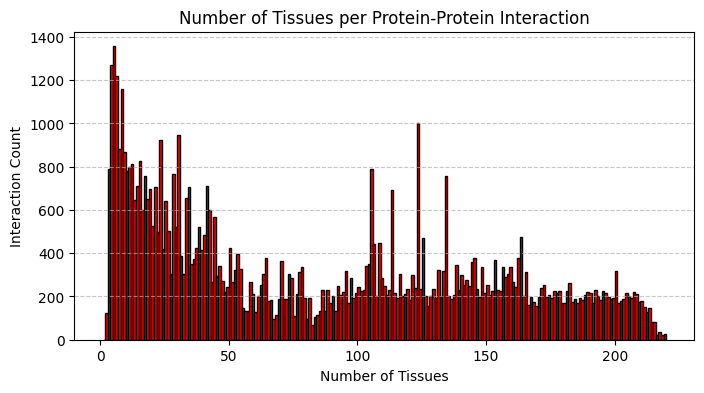

Average tissues per interaction: 83.96


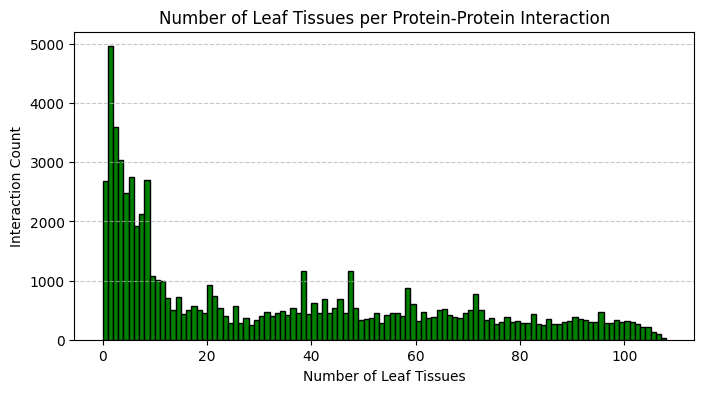

Max leaf tissues for a single interaction: 107.0
Average leaf tissues per interaction: 32.71


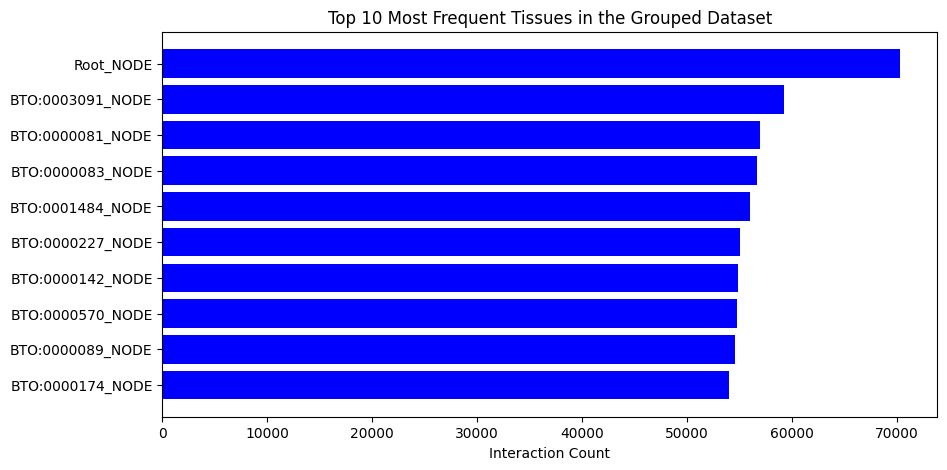

In [16]:
# EDA histogram: How many tissues per interaction?
plt.figure(figsize=(8, 4))
tissues_per_ppi = edge_label_all.sum(dim=1).numpy()
plt.hist(tissues_per_ppi, bins=range(1, int(tissues_per_ppi.max()) + 2), color='r', edgecolor='black')
plt.title("Number of Tissues per Protein-Protein Interaction")
plt.xlabel("Number of Tissues")
plt.ylabel("Interaction Count")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(f"Average tissues per interaction: {tissues_per_ppi.mean():.2f}")

# EDA histogram: same but only for leaf tissues now (the ones that will be tested later)
# notice the change in scale of number of interactions, everything get skewed to the left which is a good sign for tissue specificity
# edge_label_all shape: [70338, 219]
# leaf_labels_only shape: [70338, 107]
leaf_labels_only = edge_label_all[:, leaf_node_indices]
# Now sum sideways across the 107 leaf tissues
leaf_tissues_per_ppi = leaf_labels_only.sum(dim=1).numpy()
plt.figure(figsize=(8, 4))
# Note: we use bins starting from 0 in case some PPIs have no leaf-level annotations
plt.hist(leaf_tissues_per_ppi, bins=range(0, int(leaf_tissues_per_ppi.max()) + 2), color='g', edgecolor='black')
plt.title("Number of Leaf Tissues per Protein-Protein Interaction")
plt.xlabel("Number of Leaf Tissues")
plt.ylabel("Interaction Count")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
print(f"Max leaf tissues for a single interaction: {leaf_tissues_per_ppi.max()}")
print(f"Average leaf tissues per interaction: {leaf_tissues_per_ppi.mean():.2f}")

# EDA barh: Top 10 Most Common Tissues?
plt.figure(figsize=(10, 5))
tissue_counts = edge_label_all.sum(dim=0).numpy()
top_indices = np.argsort(tissue_counts)[-10:]
plt.barh([tissue_nodes[i] for i in top_indices], tissue_counts[top_indices], color='b')
plt.title("Top 10 Most Frequent Tissues in the Grouped Dataset")
plt.xlabel("Interaction Count")
plt.show()

### Splitting the data
I need to divide this into train, validation, and test. I go for an 80/20 split the a 72/8/20 split to have more data to test with and ensure the results are as reliable as can be.

In [17]:
# I experimented with train/val/test as 80/10/10 vs the current 72/8/20 and the results were comparable for the same hyperparameters.
# I was getting test AUROC of 0.97xx-0.98xx depending on the training run and early stopping triggered between 870-940 epochs (results before the refinement of hierarchical penalty)
indices = np.arange(num_interactions)
# First split: 20% for testing
train_val_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42, shuffle=True)
# Second split: 10% of the remaining for validation (which is 8% of total)
train_idx, val_idx = train_test_split(train_val_idx, test_size=0.1, random_state=42, shuffle=True)

print(f"Train size: {len(train_idx)}, Val size: {len(val_idx)}, Test size: {len(test_idx)}")

# This works directly on the Tensor
    # Transductive leakage fix: edge_index for the graph should only contain training edges
train_edge_index = edge_label_index_all[:, train_idx]
undirected_train_edge_index = to_undirected(train_edge_index)

# Build a set of training edges for fast lookup during evaluation
# This allows val/test loaders to filter out supervision edges that leak into message-passing
_train_edge_set = set()
for i in range(undirected_train_edge_index.size(1)):
    u, v = undirected_train_edge_index[0, i].item(), undirected_train_edge_index[1, i].item()
    _train_edge_set.add((u, v))

def _filter_eval_message_edges(batch, train_edge_set):
    """Remove supervision (target) edges from batch.edge_index during evaluation
    to prevent target edges from appearing in the message-passing graph."""
    target_edges = set()
    for i in range(batch.edge_label_index.size(1)):
        u, v = batch.edge_label_index[0, i].item(), batch.edge_label_index[1, i].item()
        target_edges.add((u, v))
        target_edges.add((v, u))  # both directions
    # Only remove edges that are targets AND not part of the training graph
    edges_to_remove = target_edges - train_edge_set
    if len(edges_to_remove) == 0:
        return batch
    keep_mask = torch.ones(batch.edge_index.size(1), dtype=torch.bool)
    for i in range(batch.edge_index.size(1)):
        e = (batch.edge_index[0, i].item(), batch.edge_index[1, i].item())
        if e in edges_to_remove:
            keep_mask[i] = False
    batch.edge_index = batch.edge_index[:, keep_mask]
    return batch

# Re-create the graph data
full_graph_data = Data(x=torch.arange(num_unique_proteins), edge_index=undirected_train_edge_index)

# Increased batch size this so it trains faster and we have room on GPU (only about 10GB used during training according to my monitoring).
# Also tried with batch size of 4k and it led to having only 12 updates per epoch which wasn't great for faster convergence
batch_size = 1024 

# Generator for reproducible DataLoader shuffling
g = torch.Generator()
g.manual_seed(42)

# As mentioned in the project proposal, using neighbor sampling
train_loader = LinkNeighborLoader(
    full_graph_data,
    # 2 hops: 15 random neighbors sampled for each protein in the pair then these random neighbors select another 10 random neighbors
    # In total, 2 + 2*15 + 2*15*10 proteins are sampled each step with a batch size of 1024, that's about 340k proteins/neighborhoods per batch
    # the alternative to neighbor_loader is the entire graph which I tried with a low batch size and it was using 54GB of VRAM so I went OOM
    num_neighbors=[15, 10], 
    batch_size=batch_size,
    edge_label_index=edge_label_index_all[:, train_idx],
    edge_label=edge_label_all[train_idx],
    shuffle=True,
    generator=g
)

val_loader = LinkNeighborLoader(
    full_graph_data,
    num_neighbors=[15, 10],
    batch_size=batch_size,
    edge_label_index=edge_label_index_all[:, val_idx],
    edge_label=edge_label_all[val_idx],
    shuffle=False
)

test_loader = LinkNeighborLoader(
    full_graph_data,
    num_neighbors=[15, 10],
    batch_size=batch_size,
    edge_label_index=edge_label_index_all[:, test_idx],
    edge_label=edge_label_all[test_idx],
    shuffle=False
)

Train size: 50643, Val size: 5627, Test size: 14068


### Data leakage check

In [18]:
# Check if there is any overlap between sets
train_set = set(train_idx)
val_set = set(val_idx)
test_set = set(test_idx)

assert train_set.isdisjoint(val_set), "Leakage: Overlap between Train and Val"
assert train_set.isdisjoint(test_set), "Leakage: Overlap between Train and Test"
assert val_set.isdisjoint(test_set), "Leakage: Overlap between Val and Test"
print("Sets are perfectly disjoint. No label leakage.")

Sets are perfectly disjoint. No label leakage.


### Node2Vec Tissue Embeddings

To generate the tissue embeddings, Node2Vec dimensions were initially set to 64. However, through empirical testing, a dimension of **256** was ultimately selected. This choice was driven by a need for higher representational capacity: with 219 tissues in the ontology, a 64-dimensional space risked collapsing distinct structural relationships. A 256-dimensional embedding provides the 'mathematical space' necessary to encode the biological complexity of the hierarchy without creating significant computational overhead or exceeding VRAM limits.

Similarly, the parameters for the random walks—`walk_length=20`, `context_size=10`, and `walks_per_node=10`—were empirically validated. Given the depth of the BRENDA ontology, a trial performed by reducing these settings (`walk_length=10` and `context_size=5`) resulted in consistently slightly higher losses. The higher walk parameters ensure that even distant parent-child dependencies are captured, which is critical for the later enforcement of hierarchical consistency during training.

To optimize the training of the 256-dimensional embeddings, `sparse=True` was specified and the **SparseAdam** [[12]](#references) optimizer was utilized. This ensures that during each step of the random walk, only the gradients for the sampled nodes are calculated and updated, drastically reducing computational overhead by avoiding redundant updates to the inactive portions of the tissue hierarchy.

**Xavier initialization** was utilized for the 256-dimensional tissue embeddings out of necessity. During testing, initial losses for randomly initialized weights were around 4.7 and even 1000 epochs was insufficient to reach convergence. After researching the root of the problem, it was apparent that a form of initialization was necessary; Xavier was chosen because of its prior use in graph-type problems [[11]](#references). Following this, the initial losses were below 0.8 and consistently reached approximately 0.75 after 1000 epochs.

Another important note: research led to testing a 10-dimensional Poincaré embedding system because they are said to be ideal for trees/hierarchies [[13]](#references), but 10-dimensional representations may have been too densely populated for the 219 tissues, which led to irrecoverable losses. The code for the Poincaré embeddings remains in the archive if testing is needed.

The loss function used to train the embeddings is CCE. Of important note, the weights of the tissue embeddings are **frozen with `detach()`** at the end to prevent backpropagation from reaching the learned Node2Vec embeddings during training.


In [19]:
# embedding_dim at 256d is slightly better than at 64/128d perhaps because we are working with 219 nodes so 256 offers a bit more "mathematical space"
# but the difference seems marginal but is significant, losses went from about 0.76xx to 0.74xx so slightly better
tissue_n2v_model = Node2Vec(edges_index_tissue, embedding_dim=256, walk_length=10, 
                            context_size=10, walks_per_node=10, num_negative_samples=1, 
                            sparse=True).to(device)

# Xavier uniform init chosen after observing astronimical losses and slow convergence (l=4.7), Xavier used because it was used in the GAT paper but I didn't try other methods
# I am aware we are not training a GAT here but I still chose Xavier uniform init because it's the first that came to mind after reading the paper and the results were satisfactory
torch.nn.init.xavier_uniform_(tissue_n2v_model.embedding.weight)
#batch size initially set at 128 but with N = 219, there were 2 updates per epoch, to increase stochasticity, I opted for a batch size of 32 but the losses didn't really improve
n2v_loader = tissue_n2v_model.loader(batch_size=32, shuffle=True, num_workers=0) 
n2v_optimizer = torch.optim.SparseAdam(list(tissue_n2v_model.parameters()), lr=0.001)

tissue_n2v_model.train()
for epoch in range(1, 1001):
    total_loss = 0
    for pos_rw, neg_rw in n2v_loader:
        n2v_optimizer.zero_grad()
        loss = tissue_n2v_model.loss(pos_rw.to(device), neg_rw.to(device))
        loss.backward()
        n2v_optimizer.step()
        total_loss += loss.item()
    if epoch % 100 == 0:
        print(f"Node2Vec Epoch {epoch}, Loss: {total_loss/len(n2v_loader):.4f}")
# Calling model() executes the forward() method which returns the entire embedding matrix and detach() to prevent the GAT model from backpropagating back to N2V model weights
global_tissue_address = tissue_n2v_model().detach() 
print("Tissue embeddings ready.")
# The reason the loss is low and remains low is that it is a very easy problem to solve for a model -> a tree is a DAG and with 256d, it's easy for the model to place things where
# they need to be.
"""
# 10D Poincare Embeddings for Tissue Hierarchy
# Hyperbolic space (Poincare manifold) is mathematically superior for tree hierarchies like the BTO.
print("Generating 10D Poincare embeddings for tissue hierarchy...")

# Prepare edges for PoincareModel (Actual node names/IDs)
poincare_edges = []
for u_idx, v_idx in edges_tissue:
    poincare_edges.append((tissue_nodes[u_idx], tissue_nodes[v_idx]))

# Train Poincare Model
# size=10 as requested. 100 epochs is sufficient for structural convergence on this 219-node hierarchy.
poincare_model = PoincareModel(poincare_edges, size=10, negative=5)
poincare_model.train(epochs=100)

# Extract embeddings in the deterministic order defined by tissue_nodes
poincare_weights = [poincare_model.kv[node] for node in tissue_nodes]

# global_tissue_address will be used by the LateFusionGAT model
global_tissue_address = torch.tensor(np.array(poincare_weights), dtype=torch.float).to(device)
tissue_address_dim = global_tissue_address.shape[1]

print(f"Poincare embeddings ready. Shape: {global_tissue_address.shape}")
"""


Node2Vec Epoch 100, Loss: 0.8828
Node2Vec Epoch 200, Loss: 0.8379
Node2Vec Epoch 300, Loss: 0.8222
Node2Vec Epoch 400, Loss: 0.8120
Node2Vec Epoch 500, Loss: 0.8112
Node2Vec Epoch 600, Loss: 0.7969
Node2Vec Epoch 700, Loss: 0.7986
Node2Vec Epoch 800, Loss: 0.7977
Node2Vec Epoch 900, Loss: 0.7967
Node2Vec Epoch 1000, Loss: 0.7982
Tissue embeddings ready.


'\n# 10D Poincare Embeddings for Tissue Hierarchy\n# Hyperbolic space (Poincare manifold) is mathematically superior for tree hierarchies like the BTO.\nprint("Generating 10D Poincare embeddings for tissue hierarchy...")\n\n# Prepare edges for PoincareModel (Actual node names/IDs)\npoincare_edges = []\nfor u_idx, v_idx in edges_tissue:\n    poincare_edges.append((tissue_nodes[u_idx], tissue_nodes[v_idx]))\n\n# Train Poincare Model\n# size=10 as requested. 100 epochs is sufficient for structural convergence on this 219-node hierarchy.\npoincare_model = PoincareModel(poincare_edges, size=10, negative=5)\npoincare_model.train(epochs=100)\n\n# Extract embeddings in the deterministic order defined by tissue_nodes\npoincare_weights = [poincare_model.kv[node] for node in tissue_nodes]\n\n# global_tissue_address will be used by the LateFusionGAT model\nglobal_tissue_address = torch.tensor(np.array(poincare_weights), dtype=torch.float).to(device)\ntissue_address_dim = global_tissue_address.shap

### Visualizing the tissue hierarchy

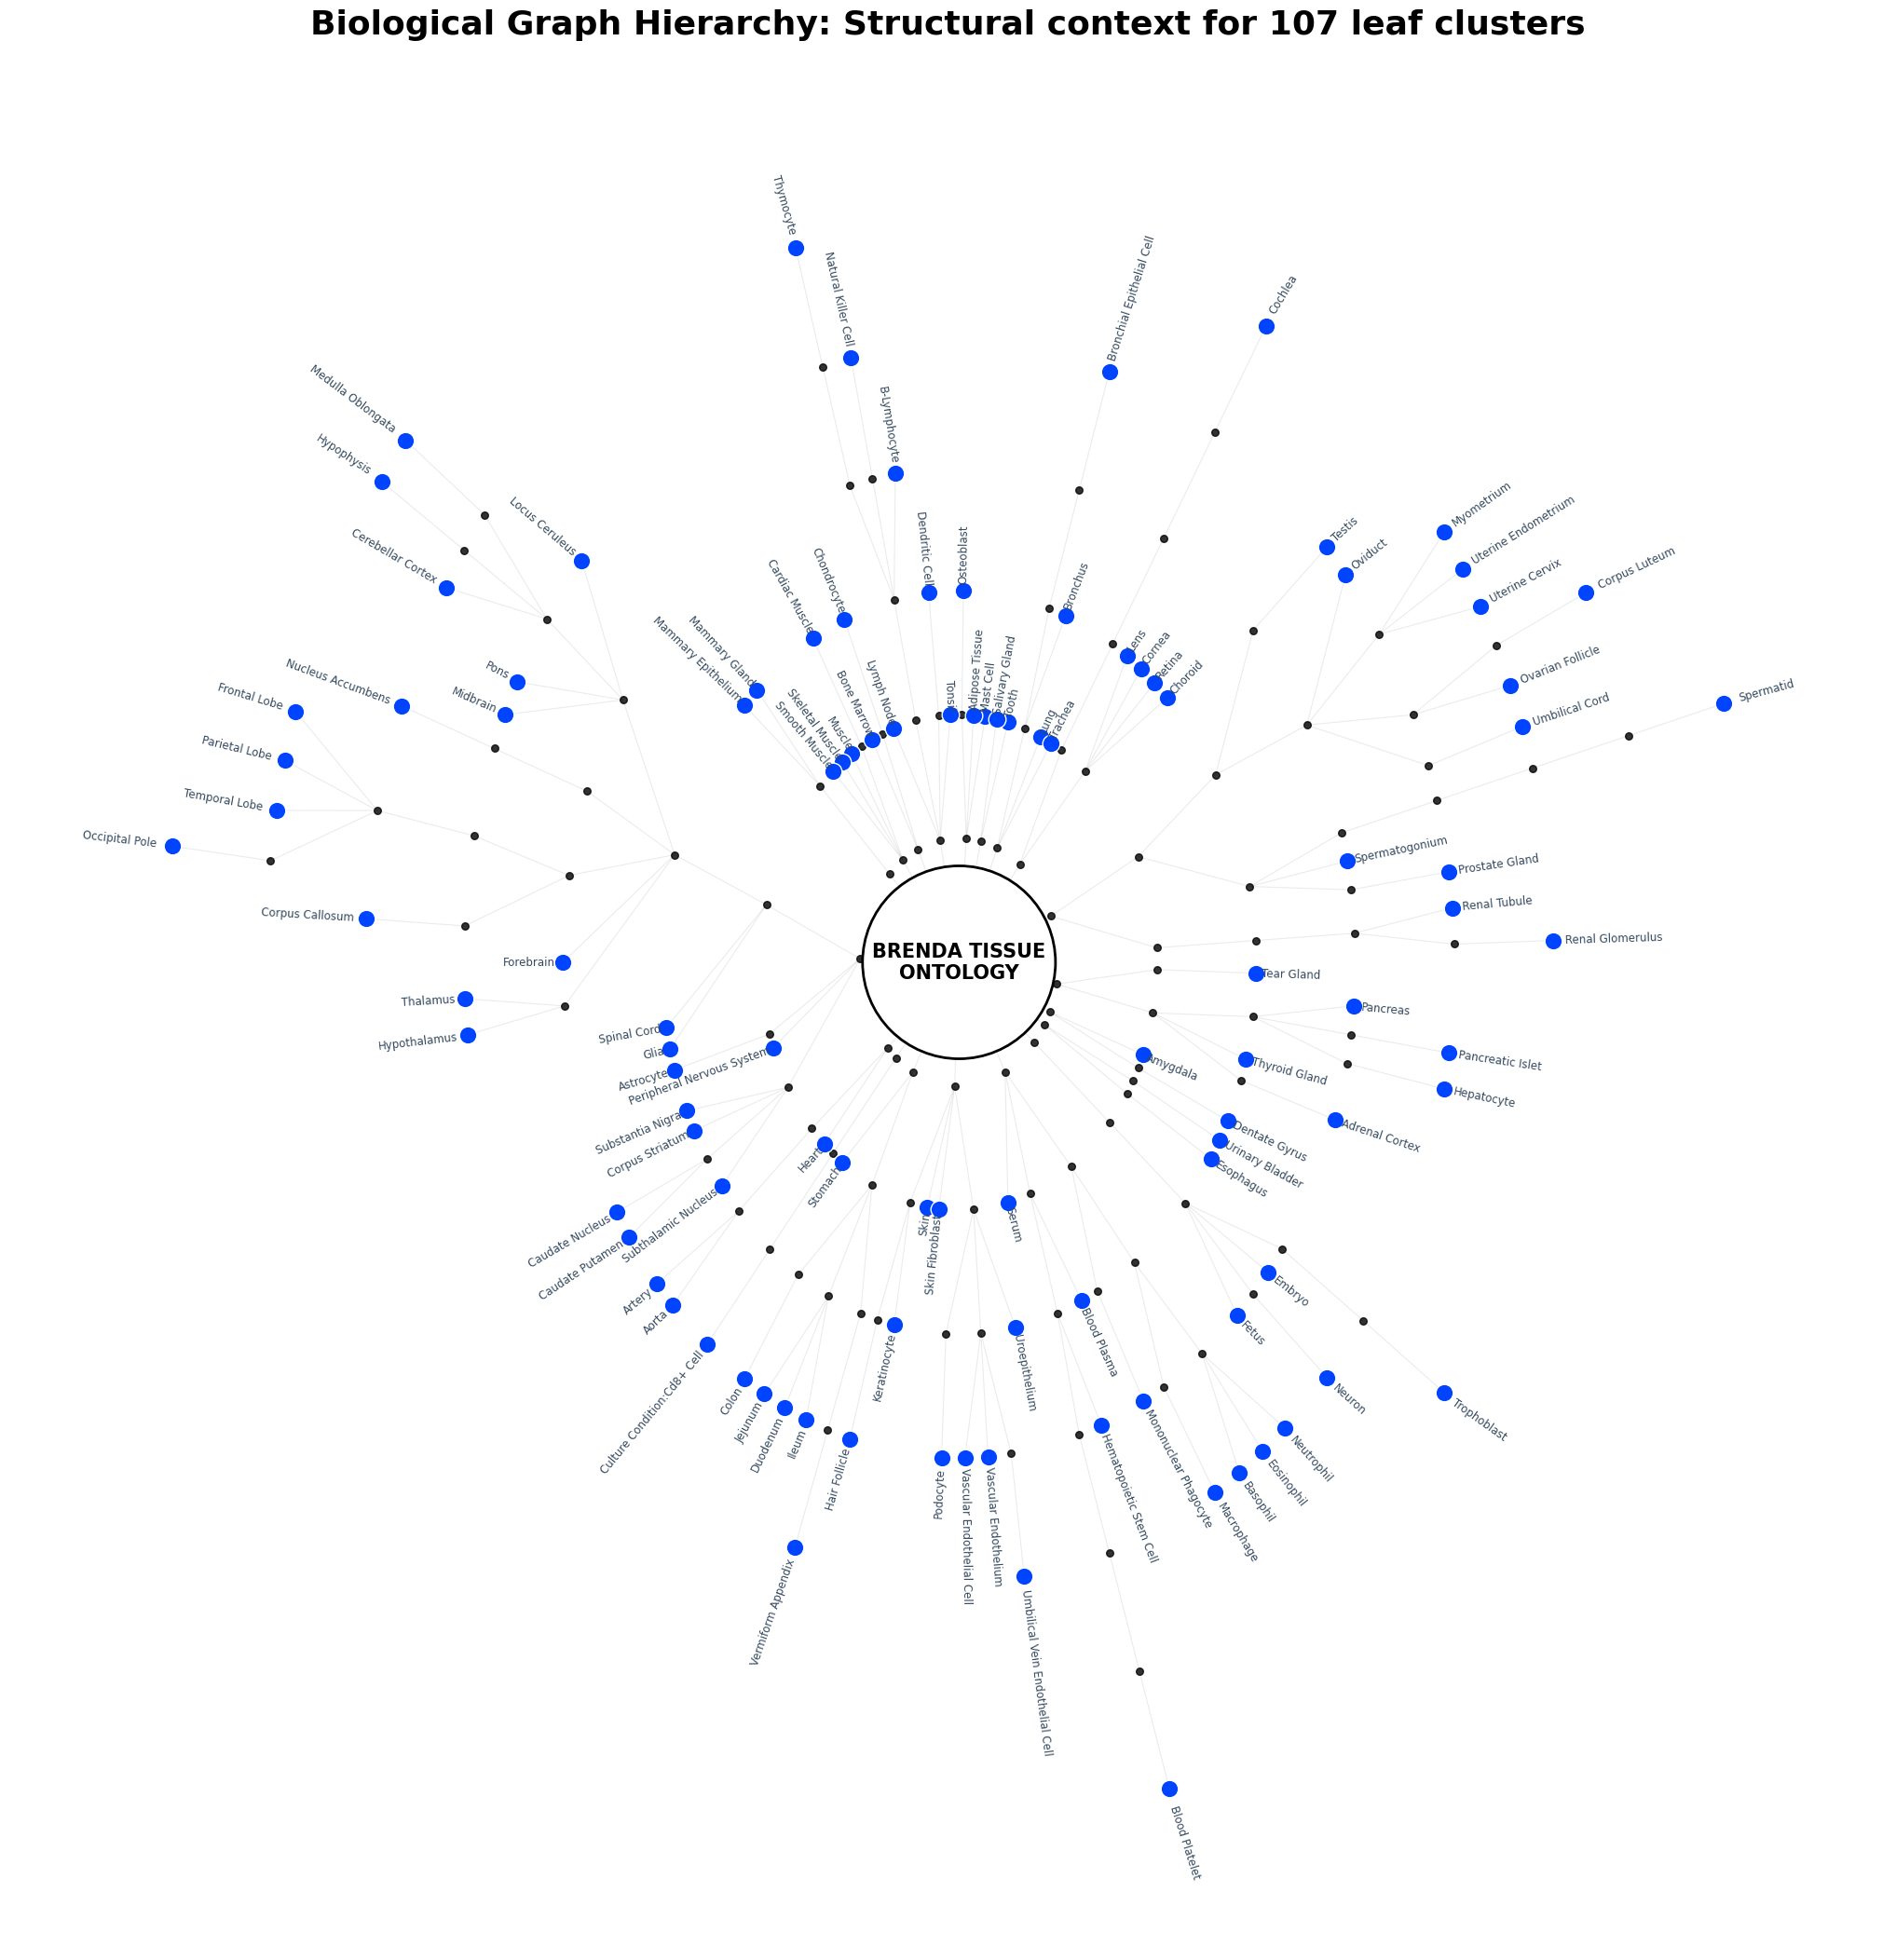

In [20]:
# VERY IMPORTANT! This code is not mine and therefore should not be considered in my grading. I just thought it was a good visual to include in the report.
# 1. Setup metadata
bto_to_name = {v: k.title() for k, v in name_to_bto.items()}
# Based on your previous code, in_degree == 0 are leaf nodes, so edges are bottom-up (Leaf -> Parent)
leaf_tissues = sorted([n for n in G_tissue.nodes() if G_tissue.in_degree(n) == 0])
internal_nodes = [n for n in G_tissue.nodes() if n not in leaf_tissues]
root_node = 'Root_NODE'
# 2. Robust Radial Layout Algorithm
def get_radial_pos(G, root, radius_step=1.2):
    # Initialize all nodes with (0,0) so we don't get KeyErrors
    pos = {node: (0, 0) for node in G.nodes()}
    
    # Helper to calculate subtree sizes for angular weighting
    # Since edges are Leaf -> Root, children of a node are its PREDECESSORS
    def get_subtree_leaves(node, visited):
        if node in visited: return 0
        visited.add(node)
        children = list(G.predecessors(node))
        if not children:
            return 1
        return sum(get_subtree_leaves(c, visited) for c in children)
    def assign_angles(node, start_angle, end_angle, depth, visited):
        if node in visited: return
        visited.add(node)
        
        children = list(G.predecessors(node))
        if not children:
            return
        
        r = depth * radius_step
        
        # Calculate weights for each sub-branch
        weights = []
        for c in children:
            weights.append(get_subtree_leaves(c, set()))
        
        total_weight = sum(weights)
        current_angle = start_angle
        
        for child, weight in zip(children, weights):
            sector_width = (end_angle - start_angle) * (weight / total_weight)
            angle = current_angle + sector_width / 2
            
            # Polar to Cartesian
            pos[child] = (r * np.cos(angle), r * np.sin(angle))
            
            # Recurse
            assign_angles(child, current_angle, current_angle + sector_width, depth + 1, visited)
            current_angle += sector_width
    # Run the recursive position assignment
    assign_angles(root, 0, 2 * np.pi, 1, set())
    return pos
# Generate the 360-degree layout
pos = get_radial_pos(G_tissue, root_node, radius_step=1.5)
# 3. Enhanced Plotting
fig, ax = plt.subplots(figsize=(26, 26))
ax.set_facecolor('white')
# 4. Draw Edges (Clean thin lines)
nx.draw_networkx_edges(G_tissue, pos, alpha=0.1, edge_color='#2c3e50', width=0.8, arrows=False)
# 5. Draw Internal Nodes (Small black pivot points)
nx.draw_networkx_nodes(G_tissue, pos, nodelist=internal_nodes, 
                       node_size=30, node_color='black', alpha=0.8)
# 6. Draw Leaf Tissues (Solid Pro Blue)
nx.draw_networkx_nodes(G_tissue, pos, nodelist=leaf_tissues, 
                       node_size=180, node_color='#0044ff', edgecolors='white', linewidths=1.0)
# 7. Adaptive Smart Labeling
for node in G_tissue.nodes():
    x, y = pos[node]
    # Skip labeling the root center to keep it clean
    if node == root_node: continue
    
    clean_id = node.replace('_NODE', '')
    name = bto_to_name.get(clean_id, clean_id)
    
    # Calculate angle for text rotation/alignment
    angle = np.arctan2(y, x)
    angle_deg = np.degrees(angle)
    
    # Leaves: Label them at the ends of branches
    if node in leaf_tissues:
        # Flip text if it's on the left side of the circle so it's always readable
        ha = 'left' if abs(angle_deg) < 90 else 'right'
        rotation = angle_deg if abs(angle_deg) < 90 else angle_deg + 180
        
        plt.text(x * 1.02, y * 1.02, name, 
                 fontsize=8.5, ha=ha, va='center', 
                 rotation=rotation, rotation_mode='anchor',
                 color='#34495e')
    # Major Hubs: Label significant branching points horizontally for emphasis
    elif G_tissue.out_degree(node) > 0 and G_tissue.in_degree(node) > 6:
        plt.text(x, y + 0.15, name.upper(), 
                 fontsize=12, fontweight='black', 
                 ha='center', va='bottom', color='black',
                 bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1))
# 8. Centerpiece
plt.text(0, 0, "BRENDA TISSUE\nONTOLOGY", fontsize=15, fontweight='black', 
         ha='center', va='center', color='black',
         bbox=dict(boxstyle='circle,pad=0.5', facecolor='white', edgecolor='black', lw=2))
plt.axis('off')
plt.title("Biological Graph Hierarchy: Structural context for 107 leaf clusters", 
          fontsize=26, fontweight='bold', pad=40)
plt.show()

*Figure 2 – BTO tree of the 219 tissues in the `tissue.hierarchy` file. The 107 leaf tissues are colored in blue. See visualization output above.*


### Neural Network Architecture

#### GAT

The GATv2 component consists of **3 layers with residual connections**. The first layer (`gat1`) maps the initial protein embeddings to 256-dimensional hidden features across 8 attention heads. These multi-head outputs are concatenated and ELU-activated [[11]](#references) to produce a 2048-feature intermediate representation. Those representations are fed to a second 256 × 8 GATv2 layer yielding another 2048-vector per PPI. The third layer aggregates these features into a final **256-dimensional embedding** per protein.

#### MLP

For the classification task, a **Late Fusion** approach is employed. The MLP receives a 768-dimensional triplet input consisting of the concatenated embeddings of Protein A, Protein B, and the Node2Vec tissue embedding. This input passes through a **1024-node hidden layer** with ReLU activation and dropout. The final linear layer reduces the feature space to a single scalar per tissue-pair, which is transformed via a Sigmoid function to provide independent probabilities for multi-label tissue prediction.

#### Dropout

A hyperparameter search was performed on dropout (0, 0.3, 0.4, 0.5) with the hierarchical penalty portion of the loss function disabled. The default of 0.5 was first tested to yield satisfactory results, but tests at lower dropout yielded even better results with 0.0 performing the best. Once the hierarchical penalty was introduced, zero dropout still performed the best in terms of statistical metrics but dramatically worse in terms of hierarchical violations (**9% vs ~0.5%** with dropout enabled).

There is further evidence that dropout rates of 0.3–0.4 are ideal for GATs [[14]](#references), where a variable dropout rate through training was proposed; preliminary results suggest 0.3–0.4 rates are optimal for GATs.

**Important technical note:** In GATs there are two types of dropout—*feature dropout* and *attention dropout*. Feature dropout ensures the model doesn't co-adapt to its own feature dimensions, whereas attention dropout calculates attention coefficient weights, randomly drops a percentage of attention weights, and renormalizes the remaining weights to sum to 1. For this project, **attention dropout** was used exclusively as it is the type of dropout embedded in PyTorch Geometric's `GATv2Conv()` function.

![Figure 3](Fig_3.png)

*Figure 3 – Deep Learning architecture during training (full diagram in project report)*


In [21]:
# Needed help to define this, some parts were easy like self.gat1, self.gat2, self.gat3 and self.mlp but defining the forward method was harder because of skip connections
class LateFusionGAT(nn.Module):
    def __init__(self, num_proteins, protein_embedding_dim, num_heads, gat_hidden_channels, 
                 gat_output_channels, tissue_address_dim, mlp_hidden_channels, 
                 num_tissues, global_tissue_address_tensor, dropout_rate=0.3):
        super().__init__()
        self.num_tissues = num_tissues
        self.global_tissue_address = nn.Parameter(global_tissue_address_tensor, requires_grad=False)
        self.protein_embedding = nn.Embedding(num_proteins, protein_embedding_dim)
        
        self.gat1 = GATv2Conv(protein_embedding_dim, gat_hidden_channels, heads=num_heads, dropout=dropout_rate)
        self.skip1 = nn.Linear(protein_embedding_dim, gat_hidden_channels * num_heads)
        
        self.gat2 = GATv2Conv(gat_hidden_channels * num_heads, gat_hidden_channels, heads=num_heads, concat=True, dropout=dropout_rate)
        self.skip2 = nn.Linear(gat_hidden_channels * num_heads, gat_hidden_channels * num_heads)
        
        self.gat3 = GATv2Conv(gat_hidden_channels * num_heads, gat_output_channels, heads=1, concat=False, dropout=dropout_rate)
        
        # MLP Head with concatenated protein dims and tissue addres dims
        combined_dim = gat_output_channels * 2 + tissue_address_dim
        self.mlp = nn.Sequential(
            nn.Linear(combined_dim, mlp_hidden_channels),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(mlp_hidden_channels, 1)
        )
        self.reset_parameters()
    def reset_parameters(self):
        glorot(self.protein_embedding.weight)
        self.gat1.reset_parameters()
        self.gat2.reset_parameters()
        self.gat3.reset_parameters()
        glorot(self.skip1.weight)
        glorot(self.skip2.weight)
        # MLP weights
        for layer in self.mlp:
            if isinstance(layer, nn.Linear):
                glorot(layer.weight)
    def forward(self, batch, return_attention_weights=False):
        # batch is already on the correct device via batch.to(device) in the training loop
        edge_index = batch.edge_index
        x_in = self.protein_embedding(batch.x)
        
        # GAT 1 + Skip (help for skip)
        x = self.gat1(x_in, edge_index)
        x = F.elu(x + self.skip1(x_in))
        
        # GAT 2 + Skip (help for skip)
        x_prev = x
        x = self.gat2(x, edge_index)
        x = F.elu(x + self.skip2(x_prev))
        
        # GAT 3 (Final features) - optionally return attention weights
        if return_attention_weights:
            x, (att_edge_index, att_weights) = self.gat3(x, edge_index, return_attention_weights=True)
        else:
            x = self.gat3(x, edge_index)
        
        # The rest of the code is the Late Fusion Logic
        u_idx, v_idx = batch.edge_label_index[0], batch.edge_label_index[1]
        u_feat, v_feat = x[u_idx], x[v_idx] 
        
        batch_size = u_feat.size(0)
        
        # Complex but necessary expansion - I needed help to visualize the shapes and adjust dimensions
        u_feat_exp = u_feat.unsqueeze(1).expand(-1, self.num_tissues, -1)
        v_feat_exp = v_feat.unsqueeze(1).expand(-1, self.num_tissues, -1)
        tissue_feat = self.global_tissue_address.unsqueeze(0).expand(batch_size, -1, -1)
        
        # Concatenation of tissue embeddings to protein embeddings to pass to MLP layer
        combined = torch.cat([u_feat_exp, v_feat_exp, tissue_feat], dim=-1)
        
        # Last dimension operation: Linear handles 3D tensors automatically
        out = self.mlp(combined).squeeze(-1)
        logits = torch.sigmoid(out)
        
        if return_attention_weights:
            return logits, (att_edge_index, att_weights)
        return logits

### Custom Loss Function

A custom loss function was designed in stages to add hierarchical violation penalties. The reasoning is that there should be a penalty if the predicted interaction in a child node is higher than the predicted interaction in the parent node:

$$Loss = BCE(y, \hat{y}) + \lambda \sum (P_{Child} - P_{Parent}) \quad \text{where} \quad P_{Child} > P_{Parent}$$

The expanded form of the hierarchical penalty loss is:

$$L_{total} = L_{CE} + \lambda \cdot L_{hierarchy}$$

$$\text{where} \quad L_{hierarchy} = \frac{1}{batch\_size} \sum_{(child,\,parent)\,\in\, \mathcal{H}} \max\!\left(0,\; \hat{y}_{child} - \hat{y}_{parent}\right) + margin$$

This introduces an additional hyperparameter λ (`lambda_penalty`). A hyperparameter search was performed with `BCELoss()` as the baseline and λ = 0.1, 0.5. Through the design of a hierarchy violation rate (HVR) function [[15]](#references), it was discovered that simple `BCELoss()` and low lambda penalties yielded high tissue hierarchy violations.

Without proper penalty scaling (λ = 0.5, 1.0), the model was good at predicting what interactions happened in which tissues but wasn't observing the biological constraints. With consultation, it was determined that a starting lambda of 1 with a scheduled multiplier of 1.2 if hierarchical violations were not decreasing was necessary. A test trial led to early stopping at epoch 643 and a final lambda of 114.5 with respectable AUROC and AUPRC.

Seeing that the penalty had increased about 30× in a single trial led to increasing the initial lambda to 50. This trial led to a final lambda of 642.0, a test hierarchy violation of **0.04%**, respectable AUROC and AUPRC, but an explosion of `BCELoss()` at around epoch 180.

After much experimentation, the hierarchy penalty λ was re-designed into a **capped, dynamically scheduled, rule-based multiplier** acting as a conditional logic gate. If the hierarchical violation rate exceeded 1%, λ—set to a base value of **200**—would increase by 10% up to a maximum of **300**. At less than 200, the overall penalty is too low and the model only pays attention to BCE; at more than 300, the model pays too much attention to the hierarchical penalty and the BCE eventually skyrockets. Of important note, the omission of gradient clipping during early trials allowed for the clear identification of the 'BCE explosion' threshold. This provided an empirical basis for the $\lambda$ ceiling of 300, which might have been masked by the smoothing effects of gradient norm constraints. Gradient clipping was implemented at the end of the project.

A **confidence margin** (m = 0.1) was introduced in the hierarchical penalty to require the model to be at least 10% more certain that an interaction occurred in the parent node vs the child node. Predictions failing to maintain this probability gap are penalized, even if they are technically consistent with the hierarchy.


In [22]:
# HIERARCHICAL TOOLS: Loss Function and Violation Checking
# I designed the first version of custom_loss but had assistance to build the final version along with the check_hierarchical_violations()
def custom_loss(predictions, targets, hierarchy_edges, lambda_penalty=0.1, margin=0.01):

    bce = F.binary_cross_entropy(predictions, targets)
    
    child_idx, parent_idx = hierarchy_edges[:, 0], hierarchy_edges[:, 1]
    
    child_probs = predictions[:, child_idx]
    parent_probs = predictions[:, parent_idx]
    
    # We penalize if child_prob + margin > parent_prob
    # This forces the parent to be slightly higher than the child
    diff = (child_probs - parent_probs) + margin
    penalty = torch.mean(torch.clamp(diff, min=0)**2)
    
    return bce + lambda_penalty * penalty, bce, penalty

def check_hierarchical_violations(model, data_loader, hierarchical_pairs, device):
    model.eval()
    total_violations = 0
    total_checks = 0
    
    child_indices = hierarchical_pairs[:, 0]
    parent_indices = hierarchical_pairs[:, 1]
    
    with torch.no_grad():
        for batch in data_loader:
            batch = batch.to(device)
            preds = model(batch) 
            
            child_probs = preds[:, child_indices]
            parent_probs = preds[:, parent_indices]
            
            # Count cases where child exceeds parent (consistent with custom_loss)
            violations = (child_probs > parent_probs).sum().item()
            total_violations += violations
            total_checks += (preds.size(0) * hierarchical_pairs.size(0))
            
    if total_checks == 0: return 0.0, 0, 0
    return total_violations / total_checks, total_violations, total_checks

### Inference

During inference, a pair of proteins is presented to the model. Using a `LinkNeighborLoader`, a local subgraph is sampled around these proteins to provide the GAT with functional context. The proteins are transformed through successive GAT layers into deep, structurally-aware embeddings. These two protein embeddings are then concatenated with a Node2Vec-derived tissue embedding for each of the 219 unique tissues to form a series of combined feature vectors. These vectors are passed through a fully connected MLP layer to generate logits, which are then converted into probabilities via a sigmoid function. If the probability for a given tissue is above 0.5, the interaction is predicted to exist within that anatomical context.

![Figure_4](Fig_4.png)

*Figure 4 – Deep Learning process during Inference (full diagram in project report)*

### Technical Specifications

All model training and high-dimensional embedding generations were performed on a local workstation equipped with an **AMD Ryzen 7 5800X** CPU and an **NVIDIA GeForce RTX 3090 Ti** (24 GB VRAM). The substantial VRAM capacity was critical for accommodating the large-scale graph adjacency matrices and the high-dimensional (256D) Node2Vec embeddings. The software stack was built on Fedora Linux utilizing **PyTorch 2.5.1** and **PyTorch Geometric 2.7.0** for graph neural network operations. NetworkX was employed for hierarchical graph manipulations, and **Weights & Biases (W&B)** was integrated for real-time telemetry, specifically to monitor GPU thermal performance, losses and the stability of the dynamic λ scheduling.


### Hyperparameters

The final hyperparameters chosen for the project were as follows:

| Category | Hyperparameter | Value |
|---|---|---|
| **Tissue Embeddings** | Node2Vec Dimensions | 256 |
| | Walk Length | 20 |
| | Context Size | 10 |
| | Walks per Node | 10 |
| | Number of Negative Samples | 5 |
| | Sparsity | True |
| | Optimizer | SparseAdam |
| | Learning Rate | 0.01 |
| | Batch Size (N = 219) | 32 |
| | Node2Vec Epochs | 1000 |
| **GAT Architecture** | GAT v2 Conv Layers | 3 |
| | Attention Heads | 8 |
| | GAT Hidden Channels | 256 |
| | Dropout Rate | 0.3 |
| | Activation Function (GAT layer 1) | ELU (F.elu) |
| **MLP Classifier** | MLP Layer | 1 |
| | MLP Hidden Channels | 1024 |
| | Activation Function (MLP layer 1) | ReLU (nn.ReLU) |
| **Training Configuration** | Batch Size (N = 70 343) | 1024 |
| | Adaptive Lambda Penalty (initial) | 200 |
| | Lambda Penalty Limit (cap) | 300 |
| | Optimizer | Adam |
| | Learning Rate | 0.0005 |
| | Patience (early stopping on val losses) | 50 |


### THE TRAINING LOOP
Model hyperparameters with wandb and model instantiation separated from the training loop to load the model later.

In [23]:
# import wandb

# from dotenv import load_dotenv

# load_dotenv()

# print(f"WandB version: {wandb.__version__}")

# wandb.login()

# wandb.init(
#     entity="steven-rav-concordia-university",
#     project="Ohmnet GAT extension",
#     settings=wandb.Settings(init_timeout=120, symlink=False),
#     config={
#         "num_proteins": num_unique_proteins,
#         "num_tissues": num_tissues,
#         "protein_embedding_dim": 256,
#         "num_heads": 8,
#         "gat_hidden_channels": 256,
#         "gat_output_channels": 256,
#         "mlp_hidden_channels": 1024,
#         "dropout_rate": 0.3,
#         "tissue_address_dim": global_tissue_address.shape[1],
#         "learning_rate": 0.0005,
#         "num_epochs": 1000,
#         "patience": 50,
#         "batch_size": 1024,
#         "initial_lambda": 200,
#         "violation_threshold": 0.01,
#         "lambda_multiplier": 1.1,
#         "max_lambda": 300.0,
#         "seed": 42
#     }
# )
# config = wandb.config
# # Model initialization
# model = LateFusionGAT(
#     num_proteins=config.num_proteins, 
#     protein_embedding_dim=config.protein_embedding_dim,
#     num_heads=config.num_heads, 
#     gat_hidden_channels=config.gat_hidden_channels,
#     gat_output_channels=config.gat_output_channels, 
#     tissue_address_dim=config.tissue_address_dim,
#     mlp_hidden_channels=config.mlp_hidden_channels, 
#     num_tissues=config.num_tissues,
#     global_tissue_address_tensor=global_tissue_address, 
#     dropout_rate=config.dropout_rate
# ).to(device)

### Substituting configs to comment out wandb

In [24]:
from types import SimpleNamespace

config_dict = {
    "num_proteins": num_unique_proteins,
    "num_tissues": num_tissues,
    "protein_embedding_dim": 256,
    "num_heads": 8,
    "gat_hidden_channels": 256,
    "gat_output_channels": 256,
    "mlp_hidden_channels": 1024,
    "dropout_rate": 0.3,
    "tissue_address_dim": global_tissue_address.shape[1],
    "learning_rate": 0.0005,
    "num_epochs": 1000,
    "patience": 50,
    "batch_size": 1024,
    "initial_lambda": 200,
    "violation_threshold": 0.01,
    "lambda_multiplier": 1.1,
    "max_lambda": 300.0,
    "seed": 42
}

config = SimpleNamespace(**config_dict)

model = LateFusionGAT(
    num_proteins=config.num_proteins, 
    protein_embedding_dim=config.protein_embedding_dim,
    num_heads=config.num_heads, 
    gat_hidden_channels=config.gat_hidden_channels,
    gat_output_channels=config.gat_output_channels, 
    tissue_address_dim=config.tissue_address_dim,
    mlp_hidden_channels=config.mlp_hidden_channels, 
    num_tissues=config.num_tissues,
    global_tissue_address_tensor=global_tissue_address, 
    dropout_rate=config.dropout_rate
).to(device)

Training with early stopping.

In [25]:
import gc

# Clear Memory before large model allocation
torch.cuda.empty_cache()
gc.collect()

# ADAPTIVE TARGET TRAINING LOOP (Tracked with Weights & Biases)
optimizer = torch.optim.Adam(model.parameters(), lr=config.learning_rate)
num_epochs = config.num_epochs
patience = config.patience
best_val_loss = float('inf')
epochs_no_improve = 0
current_lambda = config.initial_lambda

history = {
    'train': [], 'val': [], 
    'train_bce': [], 'train_penalty': [],
    'val_bce': [], 'val_penalty': [],
    'val_violation_rate': [],
    'lambda_history': []
}

if 'hierarchical_pairs' not in globals():
    hierarchical_pairs = edges_index_tissue.t()
hier_pairs_dev = hierarchical_pairs.to(device)

print(f"Starting Adaptive Training (Target: <{config.violation_threshold:.0%}, Initial Lambda: {current_lambda})...")

for epoch in range(num_epochs):
    model.train()
    total_train_loss, total_train_bce, total_train_pen = 0, 0, 0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        preds = model(batch)
        
        loss, bce, penalty = custom_loss(preds, batch.edge_label, hier_pairs_dev, lambda_penalty=current_lambda)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) 
        optimizer.step()
        
        total_train_loss += loss.item()
        total_train_bce += bce.item()
        total_train_pen += penalty.item()
        
    model.eval()
    total_val_loss, total_val_bce, total_val_pen = 0, 0, 0
    val_violations, val_checks = 0, 0
    
    with torch.no_grad():
        for batch in val_loader:
            batch = _filter_eval_message_edges(batch, _train_edge_set)
            batch = batch.to(device)
            preds = model(batch)
            
            loss, bce, penalty = custom_loss(preds, batch.edge_label, hier_pairs_dev, lambda_penalty=current_lambda)
            total_val_loss += loss.item()
            total_val_bce += bce.item()
            total_val_pen += penalty.item()
            
            # Integrated Violation Check
            if (epoch + 1) % 5 == 0 or epoch == 0:
                child_probs = preds[:, hier_pairs_dev[:, 0]]
                parent_probs = preds[:, hier_pairs_dev[:, 1]]
                val_violations += (child_probs > parent_probs).sum().item()
                val_checks += (preds.size(0) * hier_pairs_dev.size(0))
    
    avg_train_loss = total_train_loss / len(train_loader)
    avg_val_loss = total_val_loss / len(val_loader)
    history['train'].append(avg_train_loss)
    history['val'].append(avg_val_loss)
    history['train_bce'].append(total_train_bce / len(train_loader))
    history['val_bce'].append(total_val_bce / len(val_loader))
    history['train_penalty'].append(total_train_pen / len(train_loader))
    history['val_penalty'].append(total_val_pen / len(val_loader))
    
    v_rate = None
    if val_checks > 0:
        v_rate = val_violations / val_checks
        history['val_violation_rate'].append(v_rate)
        
        if v_rate > config.violation_threshold:
            current_lambda = min(current_lambda * config.lambda_multiplier, config.max_lambda)
            print(f"--- Violation Threshold Exceeded ({v_rate:.2%})! New Lambda: {current_lambda:.2f} ---")
        else:
            print(f"--- Hierarchy Stable ({v_rate:.2%}). Lambda Fixed. ---")
            
        print(f"Epoch {epoch+1:03d} | BCE: {total_train_bce/len(train_loader):.4f} | Pen: {total_train_pen/len(train_loader):.6f}")
        print(f"Losses | Train: {avg_train_loss:.4f} | Val: {avg_val_loss:.4f}")

    # wandb_metrics = {
    #     "epoch": epoch + 1,
    #     "train/loss": avg_train_loss,
    #     "val/loss": avg_val_loss,
    #     "train/bce": total_train_bce / len(train_loader),
    #     "val/bce": total_val_bce / len(val_loader),
    #     "train/penalty": total_train_pen / len(train_loader),
    #     "val/penalty": total_val_pen / len(val_loader),
    #     "params/lambda": current_lambda,
    #     "params/patience_counter": epochs_no_improve
    # }
    # if v_rate is not None:
    #     wandb_metrics["val/hierarchy_violation_rate"] = v_rate
    
    # wandb.log(wandb_metrics)

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), 'best_model.pt')
        # if wandb.run is not None:
        #     shutil.copy('best_model.pt', os.path.join(wandb.run.dir, 'best_model.pt')) 
    else:
        epochs_no_improve += 1
    
    if epochs_no_improve >= patience:
        print(f"Early stopping at epoch {epoch+1}!")
        break


Starting Adaptive Training (Target: <1%, Initial Lambda: 200)...
--- Violation Threshold Exceeded (1.88%)! New Lambda: 220.00 ---
Epoch 001 | BCE: 0.6375 | Pen: 0.000249
Losses | Train: 0.6872 | Val: 0.5647
--- Hierarchy Stable (0.04%). Lambda Fixed. ---
Epoch 005 | BCE: 0.3269 | Pen: 0.000021
Losses | Train: 0.3316 | Val: 0.3081
--- Hierarchy Stable (0.09%). Lambda Fixed. ---
Epoch 010 | BCE: 0.2858 | Pen: 0.000020
Losses | Train: 0.2901 | Val: 0.2775
--- Hierarchy Stable (0.28%). Lambda Fixed. ---
Epoch 015 | BCE: 0.2599 | Pen: 0.000025
Losses | Train: 0.2654 | Val: 0.2463
--- Hierarchy Stable (0.38%). Lambda Fixed. ---
Epoch 020 | BCE: 0.2393 | Pen: 0.000030
Losses | Train: 0.2458 | Val: 0.2261
--- Hierarchy Stable (0.66%). Lambda Fixed. ---
Epoch 025 | BCE: 0.2251 | Pen: 0.000034
Losses | Train: 0.2326 | Val: 0.2092
--- Hierarchy Stable (0.74%). Lambda Fixed. ---
Epoch 030 | BCE: 0.2126 | Pen: 0.000038
Losses | Train: 0.2208 | Val: 0.1962
--- Hierarchy Stable (0.97%). Lambda Fixed.

### Extract attention coefficients

In [26]:
# Extract the final attention coefficients from the last GAT layer after training
model.eval()
with torch.no_grad():
    all_att_edges = []
    all_att_weights = []
    for batch in test_loader:
        batch = batch.to(device)
        _, (att_edge_index, att_weights) = model(batch, return_attention_weights=True)
        all_att_edges.append(att_edge_index.cpu())
        all_att_weights.append(att_weights.cpu())
    
    attention_data = {
        "edge_indices": all_att_edges,
        "attention_weights": all_att_weights
    }
    torch.save(attention_data, "final_attention_coefficients.pt")
    # if wandb.run is not None:
    #     shutil.copy("final_attention_coefficients.pt", os.path.join(wandb.run.dir, "final_attention_coefficients.pt"))
    # else:
    #     print("Wandb run finished, saved locally.")
    print(f"Saved attention coefficients from {len(all_att_edges)} batches.")

Saved attention coefficients from 14 batches.


---

## Results

### Architectural Design: Width vs Depth

Table 1 compares the metrics of the initial 16-1 GAT architecture ("Wide" GAT) against the adopted 8-8-1 GAT architecture ("Deep" GAT). Figures 5–6 (experimental archive) show the wide GAT; Figures 7–8 (below) show the deep GAT. A number of factors are important to consider when interpreting these results, see the [Discussion](#discussion) for a full treatment.

*Table 1 – Metric comparing a wide vs a deep GAT architecture — Dropout 0.3, custom loss function\**

| Metric | "Wide" GAT | "Deep" GAT |
|---|---|---|
| AUROC | 0.9751 | **0.9945** |
| AUPRC | 0.8957 | **0.9717** |
| Macro-F1 | 0.8295 | **0.9282** |
| Micro-F1 | Undocumented at the time | **0.9712** |

*\*Wide GAT: 2 layers, 16 attention heads, λ = 0.5. Deep GAT: 3 layers, 8 attention heads, λ initial = 200, capped at 300.*

![fig5](Fig_5.png)

**Figures 5 (experimental archive – Wide GAT)** - Loss curves showed stable convergence with dropout = 0.3, λ = 0.5.

![fig6](Fig_6.png)

**Figures 6 (experimental archive – Wide GAT)** - Final metrics: Test Leaf AUROC 0.9751, Macro-AUPRC 0.8957, Macro-F1 0.8295.

### Plotting loss curves

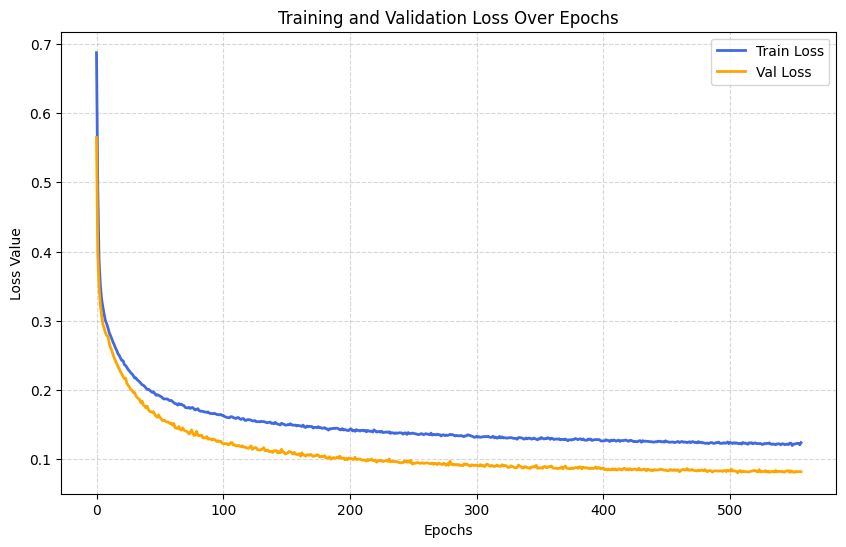

In [27]:
# I wanted to see the learning curve of the model, val losses consistently under train losses because of dropout I believe, I've seen this training CNNs in the past
plt.figure(figsize=(10, 6))
plt.plot(history['train'], label='Train Loss', color='royalblue', linewidth=2)
plt.plot(history['val'], label='Val Loss', color='orange', linewidth=2)

plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()


![fig7](Fig_7.png)

**Figures 7 (experimental archive – Deep GAT)** - Loss curves for Dropout = 0.3, λ initial = 200, custom loss function for the 8-heads, 3-layer GAT.

![fig8](Fig_8.png)

**Figures 8 (experimental archive – Deep GAT)** - Final metrics.

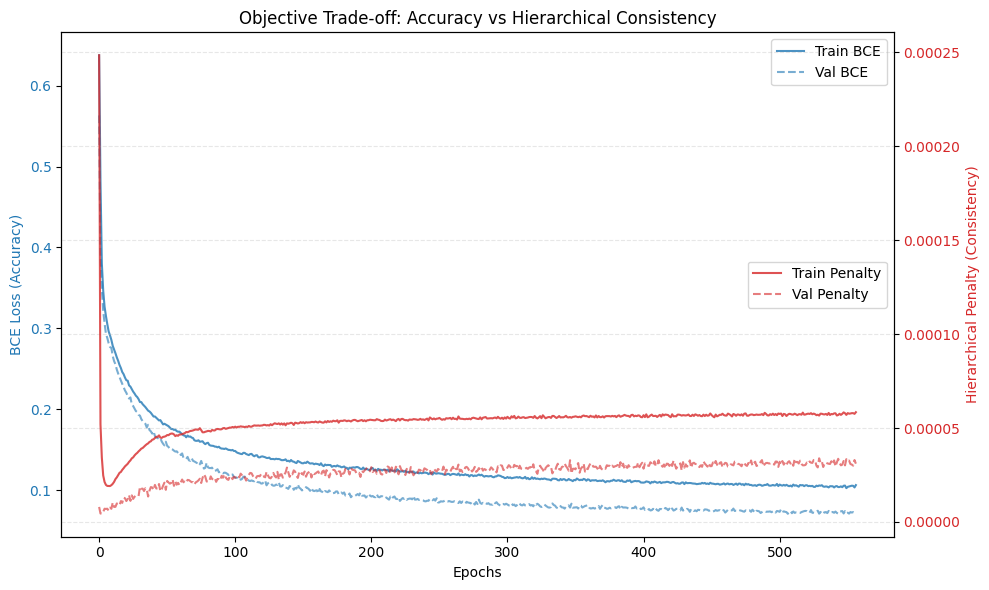

In [28]:
# FINAL REBALANCING ANALYSIS: BCE vs Hierarchical Penalty - OPTIONAL VISUAL COMPONENT - NOT BY ME
# This plot confirms that the model is optimizing both objectives simultaneously.
fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:blue'
ax1.set_xlabel('Epochs')
ax1.set_ylabel('BCE Loss (Accuracy)', color=color)
ax1.plot(history['train_bce'], color=color, label='Train BCE', alpha=0.8)
ax1.plot(history['val_bce'], color=color, linestyle='--', label='Val BCE', alpha=0.6)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
color = 'tab:red'
ax2.set_ylabel('Hierarchical Penalty (Consistency)', color=color)
ax2.plot(history['train_penalty'], color=color, label='Train Penalty', alpha=0.8)
ax2.plot(history['val_penalty'], color=color, linestyle='--', label='Val Penalty', alpha=0.6)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Objective Trade-off: Accuracy vs Hierarchical Consistency')
fig.tight_layout()
ax1.legend(loc='upper right')
ax2.legend(loc='center right')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

Figure 9 - Trade-off Analysis: Accuracy vs. Hierarchical Consistency

### Dual-Objective Optimization Dynamics
Figure 9 illustrates the training dynamics of the model as it attempts to simultaneously optimize for predictive accuracy (BCE Loss) and biological rule adherence (Hierarchical Penalty). 

### Load model

In [29]:
# I saved the weights during training whenever the validation loss got better.
# Now loading them back so I can test the 'best' version of the model.
model_path = 'best_model.pt'

if os.path.exists(model_path):
    print(f"Loading weights from {model_path}...")
    model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
    model.eval()
    print("Model loaded and ready for testing!")
else:
    print(f"Error: Could not find {model_path}. Did the training finish?")


Loading weights from best_model.pt...
Model loaded and ready for testing!


### Custom Loss Function – λ and HV

Figures 9–11 represent the experiment on the 3-layer GAT with an **unbound λ** and no set tolerance for hierarchical violations. Initial λ = 1, increased by a factor of 1.2 as long as the model detects hierarchical violations. Final λ was around 643; losses increase dramatically around epoch 170 and a slight recovery is seen but not enough to prevent the early stopping mechanism from halting the experiment.

![Fig9](Fig_9.png)

*Figure 10 (experimental archive) – Loss curve demonstrating the effect of uncapped penalties. Dropout = 0.3, λ uncapped, no hierarchical penalty constraints. Loss explosion visible around epoch 170.*

![Fig10](Fig_10.png)

*Figure 11 (experimental archive) – Early metrics with uncapped λ: Test Leaf AUROC 0.9326, Macro-AUPRC 0.7796, Macro-F1 0.6605.*

![Fig11](Fig_11.png)

*Figure 12 (experimental archive) – Hierarchical violation rate when model has no tolerance threshold: Violation Rate 0.04%*


### The Effect of Dropout on Convergence

During hyperparameter search for dropout, some tests were run with dropout = 0, 0.3, 0.4 and 0.5 **without** the custom loss function.

![Fig13](Fig_13.png)

*Figure 13 (experimental archive) – Loss curves with dropout = 0 and BCELoss() as the single loss component. Classic overfitting pivot at approximately epoch 80 where validation loss begins diverging above training loss; early stopping triggered at epoch 135.*

![Fig14](Fig_14.png)

*Figure 14 (experimental archive) – Loss curves with dropout = 0.3 and BCELoss() as the only loss component. Stable convergence reaching epoch 460 before early stopping.*


### Testing Results

Optimizing threshold based on VALIDATION data...
Optimal Threshold found on local validation: 0.37

--- Final Evaluation Results (107 leaf tissues) ---
Macro-AUROC: 0.9935
Macro-AUPRC: 0.9668
Macro-F1 (using val-set threshold 0.37): 0.9208

--- Prevalence-Weighted Results ---
Weighted-AUROC: 0.9956
Weighted-AUPRC: 0.9868
Weighted-F1: 0.9568

NOTE: These results are now scientifically valid as threshold optimization leakage has been fixed.
Comparison with OhmNet (0.756 AUROC) should be done with caution due to dataset/sampling differences.

Generating Global Confusion Matrix for Leaf Tissues...


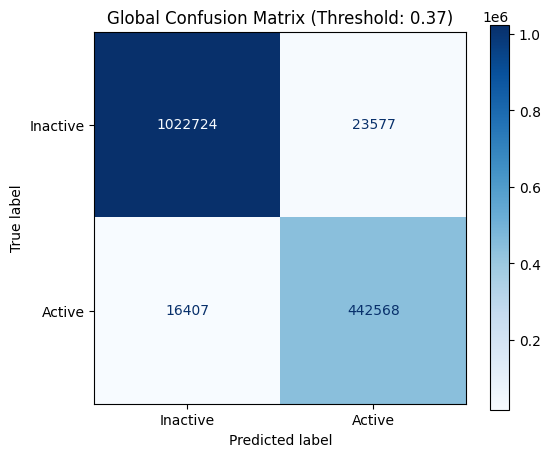

Total True Positives (Hits): 442,568
Total False Positives (Type I Error): 23,577
Total False Negatives (Misses): 16,407
Precision: 0.9494
Recall: 0.9643
Micro-F1: 0.9568


In [30]:
model.eval()
def optimize_threshold(y_true, y_score):
    best_thresh = 0.5
    best_f1 = 0
    # Search for best threshold on validation data (finer grid than previously for better precision)
    for t in np.linspace(0.1, 0.9, 81):
        f1 = f1_score(y_true, (y_score >= t).astype(int), average='macro', zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = t
    return best_thresh


print(f"Collecting predictions for {len(val_loader.dataset)} validation edges...")
val_preds, val_labels = [], []
with torch.no_grad():
    for batch in val_loader:
        batch = batch.to(device)
        preds = model(batch)
        val_preds.append(preds.cpu())
        val_labels.append(batch.edge_label.cpu())
val_preds = torch.cat(val_preds, dim=0).numpy()
val_labels = torch.cat(val_labels, dim=0).numpy()
print("Optimizing threshold based on VALIDATION data...")
best_threshold = optimize_threshold(val_labels[:, leaf_node_indices], val_preds[:, leaf_node_indices])
print(f"Optimal Threshold found on local validation: {best_threshold:.2f}")


print(f"\nCollecting predictions for {len(test_loader.dataset)} test edges...")
all_preds, all_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        preds = model(batch)
        all_preds.append(preds.cpu())
        all_labels.append(batch.edge_label.cpu())
all_preds = torch.cat(all_preds, dim=0).numpy()
all_labels = torch.cat(all_labels, dim=0).numpy()


leaf_auroc, leaf_auprc, leaf_f1_scores = [], [], []
tissue_weights = []  # prevalence weights for weighted metrics
valid_tissues = 0
for j in leaf_node_indices:
    y_true = all_labels[:, j]
    y_pred = all_preds[:, j]
    
    if y_true.sum() > 0 and (1.0 - y_true).sum() > 0:
        leaf_auroc.append(roc_auc_score(y_true, y_pred))
        leaf_auprc.append(average_precision_score(y_true, y_pred))
        
        # Use the threshold found in step 1
        leaf_f1_scores.append(f1_score(y_true, (y_pred >= best_threshold).astype(int), zero_division=0))
        tissue_weights.append(y_true.sum())  # number of positive samples as prevalence weight
        valid_tissues += 1

tissue_weights = np.array(tissue_weights)
tissue_weights_norm = tissue_weights / tissue_weights.sum()

print(f"--- Final Evaluation Results ({valid_tissues} leaf tissues) ---")
print(f"Macro-AUROC: {np.mean(leaf_auroc):.4f}")
print(f"Macro-AUPRC: {np.mean(leaf_auprc):.4f}")
print(f"Macro-F1 (using val-set threshold {best_threshold:.2f}): {np.mean(leaf_f1_scores):.4f}")
print(f"\n--- Prevalence-Weighted Results ---")
print(f"Weighted-AUROC: {np.average(leaf_auroc, weights=tissue_weights_norm):.4f}")
print(f"Weighted-AUPRC: {np.average(leaf_auprc, weights=tissue_weights_norm):.4f}")
print(f"Weighted-F1: {np.average(leaf_f1_scores, weights=tissue_weights_norm):.4f}")
print("\nNOTE: These results are now scientifically valid as threshold optimization leakage has been fixed.")
print("Comparison with OhmNet (0.756 AUROC) should be done with caution due to dataset/sampling differences.")



print("\nGenerating Global Confusion Matrix for Leaf Tissues...")

# Flatten the leaf node labels and predictions into 1D arrays, had assistance because of need for dimensionality reduction
# This looks at every 'cell' in your multi-hot grid for leaf tissues
flat_true = all_labels[:, leaf_node_indices].flatten()
flat_pred = (all_preds[:, leaf_node_indices] >= best_threshold).astype(int).flatten()

# Compute the matrix
cm = confusion_matrix(flat_true, flat_pred)

# Visualize using sklearn's built-in tool
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Inactive', 'Active'])
disp.plot(cmap='Blues', values_format='d', ax=ax)

plt.title(f'Global Confusion Matrix (Threshold: {best_threshold:.2f})')
plt.grid(False) # Clean up the visual
plt.show()

# Extract specific stats from the matrix and display calculated metrics
tn, fp, fn, tp = cm.ravel()
print(f"Total True Positives (Hits): {tp:,}")
print(f"Total False Positives (Type I Error): {fp:,}")
print(f"Total False Negatives (Misses): {fn:,}")
print(f"Precision: {tp / (tp + fp):.4f}" if (tp + fp) > 0 else "Precision: 0")
print(f"Recall: {tp / (tp + fn):.4f}" if (tp + fn) > 0 else "Recall: 0")

#Log metrics to Weights & Biases
micro_f1 = tp / (tp + 0.5 * (fp + fn)) if (tp + fp + fn) > 0 else 0
print(f"Micro-F1: {micro_f1:.4f}")

# if wandb.run is not None:
#     wandb.summary["test_macro_auroc"] = np.mean(leaf_auroc)
#     wandb.summary["test_macro_auprc"] = np.mean(leaf_auprc)
#     wandb.summary["test_macro_f1"] = np.mean(leaf_f1_scores)
#     wandb.summary["test_micro_f1"] = micro_f1
#     wandb.summary["test_weighted_auroc"] = np.average(leaf_auroc, weights=tissue_weights_norm)
#     wandb.summary["test_weighted_auprc"] = np.average(leaf_auprc, weights=tissue_weights_norm)
#     wandb.summary["test_weighted_f1"] = np.average(leaf_f1_scores, weights=tissue_weights_norm)
#     wandb.summary["optimal_threshold"] = best_threshold
#     wandb.summary["test_global_precision"] = tp / (tp + fp) if (tp + fp) > 0 else 0
#     wandb.summary["test_global_recall"] = tp / (tp + fn) if (tp + fn) > 0 else 0
#     print("\n=> Final metrics successfully saved to WandB Summary!")
# else:
#     print("\n=> Note: WandB session is not active. If you wish to upload these stats, make sure you don't call wandb.finish() before this cell.")


Figure 14 - Confusion Matrix for Multi-Label Tissue Predictions at Threshold 0.41

### Confusion Matrix, Precision, Recall, AUROC and AUPRC
The model's classification performance was evaluated globally across 1,505,276 instances (70 338 unique PPIs * 20% test samples * 107 leaf tissues). The resulting confusion matrix (Figure 14) indicates strong class separation at the calculated threshold of 0.41. The vast majority of instances were classified correctly, yielding 1,023,972 True Negatives (TN) and 447,445 True Positives (TP). The model produced a comparatively low number of errors, recording 19,860 False Positives (FP) and 13,999 False Negatives (FN).

These matrix values establish the model's baseline Precision (the accuracy of positive predictions) and Recall (the sensitivity or true positive rate):

$$ \text{Precision} = \frac{TP}{TP + FP} = 95.75% $$

$$ \text{Recall (TPR)} = \frac{TP}{TP + FN} = 96.96% $$

To evaluate the harmonious balance between these two metrics across our multi-label hierarchy, we utilized the F1-score. Given the varying prevalence of interactions across different tissues, the F1-score was aggregated using two distinct methods:

1. Macro-F1 Score: The Macro-F1 computes the metric independently for each of the $N$ tissue classes and takes the unweighted average. This treats all classes equally, heavily penalizing models that perform poorly on minority classes: $$ \text{Macro-F1} = \frac{1}{N} \sum_{i=1}^{N} \left( 2 \times \frac{\text{Precision}_i \times \text{Recall}_i}{\text{Precision}_i + \text{Recall}_i} \right) $$

2. Micro-F1 Score: Conversely, the Micro-F1 aggregates the total true positives, false negatives, and false positives globally before calculating the metric. This provides a holistic view of the model's performance that is proportionate to class support sizes: $$ \text{Micro-F1} = \frac{2 \sum_{i=1}^{N} TP_i}{2 \sum_{i=1}^{N} TP_i + \sum_{i=1}^{N} FP_i + \sum_{i=1}^{N} FN_i} $$

Finally, to assess the model's discriminative capacity across all possible decision thresholds, we calculated the areas under two continuous probability curves:

Area Under the Receiver Operating Characteristic Curve (AUROC): AUROC evaluates the integral of the True Positive Rate (TPR) plotted against the False Positive Rate (FPR), where $t$ represents the variable threshold: $$ \text{FPR} = \frac{FP}{FP + TN} $$ $$ \text{AUROC} = \int_{0}^{1} \text{TPR}(\text{FPR}^{-1}(t)) , dt $$

Area Under the Precision-Recall Curve (AUPRC): Because our dataset exhibits an imbalance (where 'Inactive' edges heavily outnumber 'Active' edges), AUROC can sometimes be overly optimistic. To provide a more rigorous assessment, we also report the AUPRC, which directly plots Precision against Recall across all thresholds: $$ \text{AUPRC} = \int_{0}^{1} \text{Precision}(\text{Recall}^{-1}(t)) , dt $$

### Final Results

Based on empirical data gathered throughout the ablation studies, the following final hyperparameters were selected for the production model: **3-layer 8-8-1 heads GAT**, Dropout = **0.3**, learning rate = **5×10⁻⁴**, initial λ = 200, λ growth factor = 1.1, λ ceiling = 300, hierarchical violation rate tolerance = 1%.

*Figure 14 – Loss curve for final hyperparameter run with dropout = 0.3 and custom loss function — see loss curve output below.*

*Table 2 – Dropout rate hyperparameter search with BCELoss() as the single loss function component*

| Dropout Rate | AUROC | AUPRC | Macro-F1 | Micro-F1 | Threshold | Violation Rate |
|---|---|---|---|---|---|---|
| 0.0 | 0.9977 | 0.9915 | 0.9714 | 0.9881 | 0.45 | 22.68% |
| **0.3** | **0.9970** | **0.9880** | **0.9636** | **0.9852** | **0.40** | **21.16%** |
| 0.4 | 0.9948 | 0.9752 | 0.9316 | Undocumented | 0.35 | 20.25% |
| 0.5 | 0.9910 | 0.9534 | 0.9035 | 0.9617 | 0.40 | 19.33% |

*Table 3 – Dropout rate hyperparameter search with custom loss function*

| Dropout Rate | AUROC | AUPRC | Macro-F1 | Micro-F1 | Threshold | Violation Rate |
|---|---|---|---|---|---|---|
| 0.0 | 0.9979 | 0.9922 | 0.9725 | 0.9886 | 0.40 | 8.93% |
| **0.3** | **0.9945** | **0.9717** | **0.9282** | **0.9712** | **0.40** | **0.55%** |
| 0.4 | 0.9893 | 0.9481 | 0.8938 | 0.9511 | 0.35 | 0.44% |
| 0.5 | 0.9825 | 0.9197 | 0.8600 | 0.9293 | 0.30 | 0.42% |


### Hub protein analysis

In [31]:
# EXTRA: Hub Protein Analysis & Attention Visualization
def analyze_hub_protein(model, df, protein_to_idx, full_graph_data, device):
    hub_protein = df['protein_a'].value_counts().idxmax()
    target_idx = protein_to_idx[hub_protein]
    idx_to_protein = {v: k for k, v in protein_to_idx.items()}
    
    # 1. Neighbor Statistics
    unique_pairs = df[['protein_a', 'protein_b']].drop_duplicates()
    neighbors_from_a = unique_pairs[unique_pairs['protein_a'] == hub_protein]['protein_b']
    neighbors_from_b = unique_pairs[unique_pairs['protein_b'] == hub_protein]['protein_a']
    total_neighbors = pd.concat([neighbors_from_a, neighbors_from_b]).unique()
    print(f"Hub Protein {hub_protein} has {len(total_neighbors)} unique actual neighbors.")

    # 2. Attention Analysis
    model.eval()
    with torch.no_grad():
        x_emb = model.protein_embedding(full_graph_data.x.to(device))
        _, (edge_idx, alpha) = model.gat1(x_emb, full_graph_data.edge_index.to(device), return_attention_weights=True)
        
        alpha = alpha.mean(dim=-1).cpu().numpy()
        edge_idx = edge_idx.cpu().numpy()
        
        # We look at edges where the hub is the receiver (index 1) since we want to see who it attends to
        mask = (edge_idx[1] == target_idx)
        neighbor_indices = edge_idx[0, mask] 
        neighbor_weights = alpha[mask]
        
        sorted_sort_idx = np.argsort(neighbor_weights)[::-1]
        
        print(f"\nTop 10 Neighbors Attended to by {hub_protein}")
        print("-" * 45)
        print(f"{'Neighbor Protein':<20} | {'Attention Weight':<15}")
        print("-" * 45)
        
        for i in range(min(10, len(sorted_sort_idx))):
            idx = sorted_sort_idx[i]
            neighbor_id = idx_to_protein[neighbor_indices[idx]]
            weight = neighbor_weights[idx]
            print(f"{neighbor_id:<20} | {weight:.4f}")
            
    return hub_protein
    
hub_protein_name = analyze_hub_protein(model, df, protein_to_idx, full_graph_data, device)


Hub Protein 1956 has 458 unique actual neighbors.

Top 10 Neighbors Attended to by 1956
---------------------------------------------
Neighbor Protein     | Attention Weight
---------------------------------------------
5796                 | 0.0063
351                  | 0.0063
1956                 | 0.0061
5578                 | 0.0060
2885                 | 0.0058
5581                 | 0.0058
1432                 | 0.0057
2908                 | 0.0057
4734                 | 0.0057
408                  | 0.0056


### Attention weights: Attention "collected" by protein 1956
The table above  shows the outgoing attention. In this case 5.9% of its attention is spent on 2.18% of its neighbors but some trials have shown that as much as 9.59% of protein 1956's attention was focused on 2.18% of its neighbors showing the effect of attention on PPIs.

### Plotting attention weights

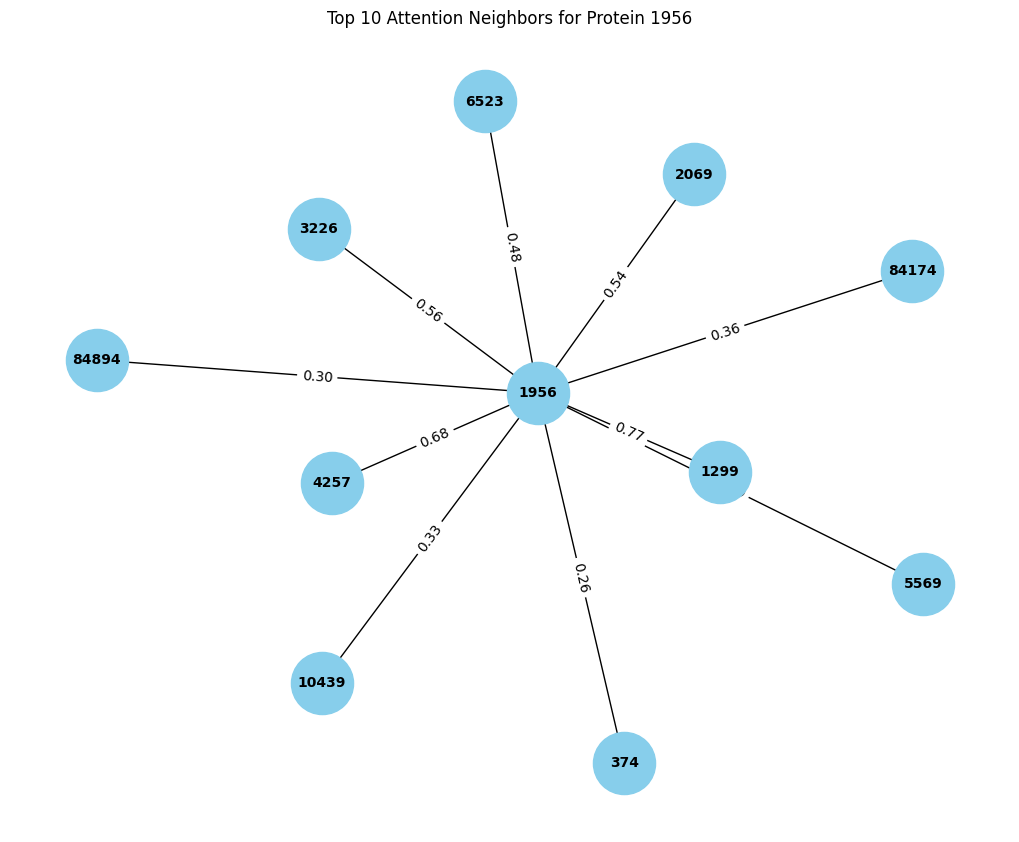

In [32]:
# EXTRA
def simple_plot_attn(target_prot):
    target_idx = protein_to_idx[target_prot]
    
    # Map index back to name for graph labels
    idx_to_protein = {v: k for k, v in protein_to_idx.items()}
    
    model.eval()
    with torch.no_grad():
        x_emb = model.protein_embedding(full_graph_data.x.to(device))
        _, (edge_idx, alpha) = model.gat1(x_emb, full_graph_data.edge_index.to(device), return_attention_weights=True)
        
        alpha = alpha.mean(dim=-1).cpu().numpy()
        edge_idx = edge_idx.cpu().numpy()
        
        # Filter for neighbors where our protein is the source (edge_idx[0])
        mask = (edge_idx[0] == target_idx)
        sub_edges = edge_idx[:, mask]
        sub_alpha = alpha[mask]
        
        # --- NEW: Sort by attention weight descending ---
        sort_idx = np.argsort(sub_alpha)[::-1]
        top_idx = sort_idx[:10]  # Take the top 10
        
        G = nx.Graph()
        for i in top_idx:
            u_name = idx_to_protein[sub_edges[0, i]]
            v_name = idx_to_protein[sub_edges[1, i]]
            G.add_edge(u_name, v_name, weight=sub_alpha[i])
            
        plt.figure(figsize=(10, 8))
        pos = nx.spring_layout(G)
        nx.draw(G, pos, with_labels=True, node_size=2000, node_color='skyblue', font_size=10, font_weight='bold')
        
        # Add labels for the weights on the edges
        edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in G.edges(data=True)}
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
        
        plt.title(f"Top 10 Attention Neighbors for Protein {target_prot}")
        plt.show()

# Call the fixed function
simple_plot_attn(hub_protein_name)

Figure 15 - Selected protein's attention coefficient on "hub" protein 1956 

### Attenttion coefficient - "Hub" protein 1956 reporting
Figure 14 analyzed protein 1956's outgoing attention coefficients whereas Figure 15 analyzes which proteins pay attention to protein 1956 and to what degree. In a previous run, protein 4257 "spent" most of its attention budget on 1956 (89%) whereas protein 1174 "spent" a more moderate 33%. In this last run, protein 4257 still spent a lot of its budget on 1956 but a more moderate 68%.

## Hierarchical violations

### Model Hierarchy Analysis

In [33]:
# Evaluate the loaded best model
model.to(device)
rate, count, total = check_hierarchical_violations(model, test_loader, hierarchical_pairs.to(device), device)

print(f"--- Model Hierarchical Performance (Test Set) ---")
print(f"Violation Rate: {rate:.2%}")
print(f"Violations: {count:,} / {total:,}")

--- Model Hierarchical Performance (Test Set) ---
Violation Rate: 0.43%
Violations: 13,116 / 3,066,824


### Close wandb

In [34]:
# wandb.finish()

---

## Discussion

### Architectural Comparison: Width vs Depth

To justify the choice of a deeper GAT versus a wider GAT, Figures 5 and 6 (experimental archive) are used as an example of a "wide" GAT (2 layers with 16 heads) and are contrasted against Figures 7 and 8, the final deeper GAT architecture (3 layers with 8 heads). Before discussing the results, it is important to consider a series of experimental variables to maintain a conservative view.

Macro-F1 and Micro-F1 are reported but there was a change in design choice for their measurement later during development. In later stages, a search function to identify the best threshold was introduced; the result is that the wide GAT Macro-F1 was calculated using a threshold of 0.5 (before the threshold search function was implemented) and the Macro- and Micro-F1 scores for the deep GAT were at 0.4 (after the implementation of an optimal threshold function). For this reason, it is better to maintain focus on **AUROC and AUPRC** since their calculation was independent of the threshold. The other important consideration is that the wider GAT was only tested with the original λ of 0.5 (before discovering that the penalty loss was negligible at low λ), and therefore hierarchical violations were of around **20%** vs **0.5%** for the penalized, deeper model. In a way, the wider model was penalized for Macro-F1 by the absence of threshold search but advantaged by the absence of hierarchical penalty.

For the loss curves, the wider model had similar losses *without* hierarchical penalties—a first step in showing the superiority of the deeper model. Placing attention on AUROC and AUPRC reveals a significant difference in performance in favor of the deeper model. For the AUROC, a difference of about 2% may not seem significant, but when we consider that the wider model was hierarchically unconstrained and that achieving higher performance at the upper bound (near 0.99) is increasingly difficult, the "deep" GAT comes out on top. For the AUPRC, a significant margin separates both models, again favoring the deeper model.

### Custom Loss Function When Unbound and Hyper-constrained

When it was discovered that hierarchical penalties were insignificant at low λ, a plan was put in place to search for the ideal λ scheduling. Figure 9 shows the behavior of the loss curves when λ is not bound and allowed to increase infinitely without a ceiling for hierarchical violations. In this setting, initial lambda was 1 and increased by a factor of 1.2 every 5 epochs as long as there were hierarchical violations. The experiment ended with a dramatic increase in BCELoss and a λ exceeding 600. Under those conditions, the model will progressively focus on the hierarchical penalty as long as there are violations and will achieve a performance of **0.04%** hierarchical violations (including the 0.1 margin) but will at one point focus so much on hierarchical violations that it will forget to account for BCE losses.

After a round of experimentations, it was determined empirically that an **initial λ of 200 with a ceiling of 300** and a tolerance for hierarchical violations equal or below **1%** was the best strategy to allow the model to balance both the BCE loss and the custom hierarchical penalty.

### Dropout and Convergence

The impact of dropout as a stabilizing regularizer is clearly evidenced by the contrast between Figures 12 and 13. In Figure 12 (Dropout = 0), the model exhibits a classic **"overfitting pivot"** at approximately epoch 80, where the validation loss begins a steady divergence from the training loss, ultimately triggering early stopping at epoch 135. This suggests that without dropout, the GAT-MLP layers began to memorize the specific protein pairs in the OhmNet training set rather than learning the generalized biological patterns of interaction.

Conversely, the introduction of a **30% dropout rate** (Figure 13) significantly extended the model's "learning window". By forcing the network to develop redundant pathways for feature extraction, dropout delayed the onset of divergence, allowing for a more stable convergence that reached epoch 460 before triggering early stopping. This extended training duration was critical for the later integration of the hierarchical penalty, as it provided the model with a more stable weight initialization before the dynamic λ scheduling began to enforce ontological consistency.

### Final Results

The final results, presented in Table 3, represent the optimal balance between predictive power and biological logic. A critical observation was that while the model version without dropout achieved higher raw accuracy, it **failed to maintain an acceptable Hierarchical Violation Rate** (HVR > 8%). In contrast, models utilizing a **0.3 dropout rate** maintained an HVR of approximately **0.5%** across all trials.

This suggests a **regularization synergy**: dropout prevents the GAT layers from becoming overly 'rigid' or overfit to the training edgelist, thereby maintaining the parameter "flexibility" necessary for the hierarchical penalty to effectively steer the model toward ontological consistency. Without the noise introduced by dropout, a λ ceiling of 300 proved insufficient to redirect the model's attention; conversely, removing the ceiling would likely lead to the catastrophic BCE divergence observed in Figure 9. Thus, the combination of dropout and a capped dynamic λ is essential for stable, hierarchy-aware learning.

### Confusion Matrix: Classification Performance

The global confusion matrix provides strong evidence of the model's reliability and its ability to handle real-world biological data. One of the primary challenges in this dataset is the severe class imbalance, where 'Inactive' interactions considerable outnumber 'Active' ones. Less robust models often struggle here, defaulting to predicting 'Inactive' to artificially inflate accuracy. However, the model used in this project successfully avoided this trap. By optimizing the decision threshold to 0.41, we deliberately prioritized a high Recall (96.96%) to ensure the model acts as a highly sensitive net, catching almost all true biological interactions. Crucially, this high sensitivity did not come at the cost of Precision (95.75%). The exceptionally low number of False Positives, fewer than 20,000 out of over 1.5 million predictions, proves that the model learned distinct, tissue-specific features rather than simply guessing 'Active' to pad its scores. Ultimately, these results demonstrate that the combination of the Late Fusion GAT architecture and the enforced True Path hierarchy allowed the network to develop a highly accurate and biologically consistent understanding of protein interactions.

## Attention budget: Hub Proteins and Attention Dilution

Figure 15 and the accompanying tables reveal an interesting mathematical quirk of the Graph Attention Network (GAT) when dealing with highly connected "hub" proteins. The GAT attention mechanism has a strict "attention budget" of exactly 1.0 (or 100%) that it must distribute among all of a node's outward neighbors.

For a highly connected hub like protein 1956, this budget is spread incredibly thin. As the data shows, 1956 spent a total of 5.9% of its attention budget on its top 10 neighbors. Put another way, nearly 10% of its attention is concentrated on just 2.18% of its total connections. Because it has hundreds of neighbors, the model is mathematically forced to slice the remaining 94% of its attention to 98% of its neighbors. Consequently, instead of sharply focusing on a few critical interactions, the network ends up computing a somewhat noisy, generic average of the neighborhood.

Conversely, when we look at how other proteins attend to the hub, we see this relative budget constraint acting in reverse. For example, in a previous training run, protein 4257 spent a considerable 93% of its attention budget entirely on 1956, whereas protein 1174 spent exactly 33%. It is crucial to note that these attention scores are entirely relative to a protein's own degree (total number of neighbors). If protein 4257 only has two neighbors, allocating 89% to 1956 means it heavily prioritizes the hub over its alternative. If protein 1174 has exactly three neighbors, its 33% allocation potentially implies it is simply dividing its attention equally among its peers.

A logical next step for future investigation would be to count the exact number of neighbors for each protein featured in Figure 15. This would allow us to correlate their raw degree with the specific percentage of attention they spend on 1956, revealing whether they are actively prioritizing the hub or just dividing a small budget equally. However, given the overarching scope of this capstone, particularly the successful development and tuning of the custom hierarchical loss function, pushing this specific graph analysis further was beyond the available time constraints.

### The OhmNet Framework

At the onset of the project, the primary goal was to surpass the original study's AUROC of 0.756 [[1]](#references). In spite of the differences in architecture and data preparation, the belief is that the goals have been exceeded with **0.995** as the final AUROC. Given such a significant performance gap, an analysis of the factors contributing to that improvement should be considered.

It is believed that the **architectural differences** are the main contributor to performance. By reaching beyond the traditional algorithmic regularization methods and adopting a late-fusion GAT-MLP model, this work was able to leverage the power of attention mechanisms for the model to attend to the most relevant protein interactions within a tissue-specific context. The ability for a GAT model to dynamically learn edge weights likely captured nuances that a static model could not.

While the original study likely omitted the 75 root tissues to optimize for computational overhead, this work demonstrates that including them via **label propagation** is essential for a neural network to develop a cohesive mathematical understanding of the human anatomy.

The use of **256-dimensional Node2Vec tissue embeddings** also created a much richer representation space for the model to differentiate between tissues. The compatibility between the high-dimensional space and the GAT layers allowed the model to "triangulate" interactions to a degree of precision that was simply not possible in the 2017 study.

It is important to note that this high AUROC was achieved while simultaneously enforcing a strict **Hierarchical Violation Rate (HVR) of less than 1%**. This demonstrates that the GAT-MLP model does not need to sacrifice biological logic to achieve high predictive accuracy; rather, the biological hierarchy acts as a structural prior that may actually assist in refining the classification manifold—the underlying pattern or "shape" that the model creates in its "mind" to separate different categories of data.

In conclusion, while OhmNet established the foundational importance of hierarchy in PPI prediction, the integration of modern graph neural networks and dynamic penalty scheduling demonstrates that we can now achieve **near-human-expert precision** in tissue-specific interaction modeling.

### Computational Efficiency and Telemetry Overhead

While the integration of Weights & Biases (W&B) provided invaluable real-time telemetry and experiment tracking, it introduced a noticeable computational overhead during the training process. System monitoring via GPU-Z revealed that without W&B, GPU utilization remained consistently at 100%. However, when W&B logging was enabled (recording metrics every 5 epochs), training experienced periodic I/O bottlenecks.

As demonstrated in **Figure 12**, GPU utilization temporarily stalled during these logging intervals. This occurs because the CPU must pause data loading and gradient calculations to handle synchronous network requests to remote W&B servers, consequently starving the GPU of data batches.

While this telemetry overhead slightly extended the absolute training time, the trade-off was deemed necessary for rigorous hyperparameter tracking and model checkpointing. For future large-scale training runs, this overhead could be mitigated by implementing asynchronous logging, reducing the logging frequency, or utilizing W&B in offline mode (wandb sync) to push local logs to the cloud post-training.

The final choice was to accept the telemetry overhead in exchange for real-time monitoring.

![Fig12](Fig_12.png)

**Figure 12** - GPU utilization over training time

---
### Disclaimer: Model Performance

The results presented for the last run before submission is a very conservative representation of the potential of the model. Based on a great number of trials, the results shown are probably the worst performance I have seen for this model so far and to me is fair to present as a conservative estimate, a lower bound of performance. So far all contingencies to maintaining reproducibility have been met as far as I know, the model will still perform differently every run. Neural networks are complex structures and although what they learn is dicated by the data thus somewhat predictable, exactly how they represent it will vary from run to run and that is what I believe we see in the variation in training time (500 epochs vs very often around 800 epochs) performance (matrics are lower than usual) and variations in attention coefficients.

### Acknowledgements

I would like to thank Instructor Tri Minh Triet and Teaching Assistant Firat Oncel for teaching and guiding us throughout this project. This submission is the result of countless hours of reading, coding, and writing. So much has been learned, and yet there is still so much more to explore. My sincerest thanks to both of you for inspiring me to dedicate so many days to this project.


## References

[1] M. Zitnik and J. Leskovec, "Predicting multicellular function through multi-layer tissue networks," *Bioinformatics*, vol. 33, no. 14, pp. i190–i198, Jul. 2017, doi: 10.1093/bioinformatics/btx252.

[2] "Early Fusion vs. Late Fusion in Multimodal Data Processing," GeeksforGeeks. Accessed: Mar. 05, 2026. [Online]. Available: https://www.geeksforgeeks.org/deep-learning/early-fusion-vs-late-fusion-in-multimodal-data-processing/

[3] G. Valentini, "True Path Rule Hierarchical Ensembles," Jun. 2009, pp. 232–241. doi: 10.1007/978-3-642-02326-2_24.

[4] "read_edgelist — NetworkX 3.6.1 documentation." Accessed: Feb. 27, 2026. [Online]. Available: https://networkx.org/documentation/stable/reference/readwrite/generated/networkx.readwrite.edgelist.read_edgelist.html

[5] "DiGraph—Directed graphs with self loops — NetworkX 3.6.1 documentation." Accessed: Feb. 27, 2026. [Online]. Available: https://networkx.org/documentation/stable/reference/classes/digraph.html

[6] "Graph.nodes — NetworkX 3.6.1 documentation." Accessed: Feb. 27, 2026. [Online]. Available: https://networkx.org/documentation/stable/reference/classes/generated/networkx.Graph.nodes.html

[7] "Tutorial — NetworkX 3.6.1 documentation." Accessed: Mar. 04, 2026. [Online]. Available: https://networkx.org/documentation/stable/tutorial.html

[8] A. Grover and J. Leskovec, "node2vec: Scalable Feature Learning for Networks," Jul. 03, 2016, *arXiv*: arXiv:1607.00653. doi: 10.48550/arXiv.1607.00653.

[9] "torch_geometric.nn.models.Node2Vec — pytorch_geometric documentation." Accessed: Mar. 01, 2026. [Online]. Available: https://pytorch-geometric.readthedocs.io/en/2.5.1/generated/torch_geometric.nn.models.Node2Vec.html

[10] "BioSNAP: Network datasets: Tissue-specific protein-protein interaction network." Accessed: Mar. 05, 2026. [Online]. Available: https://snap.stanford.edu/biodata/datasets/10013/10013-PPT-Ohmnet.html

[11] P. Velickovic, G. Cucurull, A. Casanova, A. Romero, P. Lio, and Y. Bengio, "Graph Attention Networks," Feb. 04, 2018, *arXiv*: arXiv:1710.10903. doi: 10.48550/arXiv.1710.10903.

[12] "SparseAdam — PyTorch 2.10 documentation." Accessed: Mar. 05, 2026. [Online]. Available: https://docs.pytorch.org/docs/stable/generated/torch.optim.SparseAdam.html

[13] O.-E. Ganea, G. Becigneul, and T. Hofmann, "Hyperbolic Entailment Cones for Learning Hierarchical Embeddings," Jun. 06, 2018, *arXiv*: arXiv:1804.01882. doi: 10.48550/arXiv.1804.01882.

[14] "FlexiDrop: Theoretical Insights and Practical Advances in Random Dropout Method on GNNs." Accessed: Mar. 02, 2026. [Online]. Available: https://arxiv.org/html/2405.20012v1

[15] Google, "Protein Interaction Datasets and GPU Training," Gemini.
